
                                                                Addis Ababa University


                                                    Data science and cloud computing for Bioinformatics
                                                               Module -3 Assignment 
                                              
                                                               Name: Beyene Chalchisa
                                              
                                                                  ID NO: GSR/4596/18

                
                                                                  Study to reproduce 
                                                                 
# Himes BE et al. (2014)

RNA-Seq Transcriptome Profiling Identifies CRISPLD2 as a
Glucocorticoid Responsive Gene.

# Objective

To reproduce the comparison between dexamethasone (DEX)-treated
and untreated airway smooth muscle cell samples using RNA-seq data
from GEO dataset GSE52778.

    

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
#Part 2 — Obtain the public data  
from pathlib import Path

folders = [
    "project/data/raw",
    "project/data/processed",
    "project/notebooks",
    "project/results/tables",
    "project/results/figures"]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [53]:
from pathlib import Path

In [2]:
print(Path("project").resolve())

C:\Users\user\project


In [3]:
# Go to the GEO dataset

Path("project/data/processed").mkdir(parents=True, exist_ok=True)

In [4]:

processed_folder = Path("project/data/processed")
print(processed_folder.resolve())

C:\Users\user\project\data\processed


In [1]:
from pathlib import Path

processed_folder = Path("project/data/processed")

print(processed_folder.resolve())

C:\Users\user\project\data\processed


In [2]:


folder = Path(r"C:\Users\user\project\data\processed")

print("Files in the processed folder:")
for file in folder.iterdir():
    print(file.name)

Files in the processed folder:
gene_value_table.xlsx
GSE52778_All_Sample_FPKM_Matrix.txt
GSE52778_Dex_vs_Untreated_gene_exp.diff
GSE52778_expression_data.csv
GSE52778_series_matrix.txt
GSE52778_series_matrix1.csv


In [30]:
import pandas as pd
input_file = r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt"


df = pd.read_csv(input_file, sep="\t")

df.to_csv(input_file, index=False)

print("CSV file created successfully!")
print(df.head())

CSV file created successfully!
  gene_id tracking_id class_code nearest_ref_id gene_short_name tss_id locus length coverage Dex_FPKM Dex_conf_lo Dex_conf_hi Dex_status Alb_FPKM Alb_conf_lo Alb_conf_hi Alb_status Untreated_FPKM Untreated_conf_lo Untreated_conf_hi Untreated_status Alb_Dex_FPKM Alb_Dex_conf_lo Alb_Dex_conf_hi Alb_Dex_status Dex_LL14 Dex_LL06 Dex_LL02 Dex_LL10 Alb_LL07 Alb_LL03 Alb_LL11 Alb_LL15 Untreated_LL09 Untreated_LL05 Untreated_LL13 Untreated_LL01 Alb_Dex_LL08 Alb_Dex_LL04 Alb_Dex_LL12 Alb_Dex_LL16
0  1/2-SBSRNA4 1/2-SBSRNA4 - - 1/2-SBSRNA4 TSS173...                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [73]:
#to see column
input_file = r"C:\Users\user\project\data\processed\GSE52778_Dex_vs_Untreated_gene_exp.diff"

df = pd.read_csv(input_file, sep="\t")

df.head()


,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant
0,1/2-SBSRNA4,1/2-SBSRNA4,1/2-SBSRNA4,chr4:110351118-110461615,Dex,Untreated,OK,0.326909,0.355693,0.121744,-0.027231,0.978275,0.999906,no
1,A1BG,A1BG,A1BG,chr19:58858171-58874214,Dex,Untreated,OK,3.990910,3.020000,-0.402168,0.618881,0.535995,0.999906,no
2,A1BG-AS1,A1BG-AS1,A1BG-AS1,chr19:58858171-58874214,Dex,Untreated,OK,2.308720,1.409940,-0.711454,0.869443,0.384605,0.999906,no
3,A1CF,A1CF,A1CF,chr10:52559168-52645435,Dex,Untreated,NOTEST,0.002150,0.004012,0.899812,-0.189467,0.849727,1.000000,no
4,A2LD1,A2LD1,A2LD1,chr13:100741268-101241046,Dex,Untreated,OK,1.542480,1.494600,-0.045497,0.053045,0.957696,0.999906,no


In [74]:
#To remove unwanted column
# Columns to remove
Dex_vs_Untreated_gene_exp = [
    "log2(fold_change)",
    "test_stat",
    "p_value",
    "q_value",
    "significant",
    "test_id"]

# Remove the columns
df = df.drop(columns=Dex_vs_Untreated_gene_exp, errors="ignore")

# Display first 5 rows
df.head()

,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2
0,1/2-SBSRNA4,1/2-SBSRNA4,chr4:110351118-110461615,Dex,Untreated,OK,0.326909,0.355693
1,A1BG,A1BG,chr19:58858171-58874214,Dex,Untreated,OK,3.990910,3.020000
2,A1BG-AS1,A1BG-AS1,chr19:58858171-58874214,Dex,Untreated,OK,2.308720,1.409940
3,A1CF,A1CF,chr10:52559168-52645435,Dex,Untreated,NOTEST,0.002150,0.004012
4,A2LD1,A2LD1,chr13:100741268-101241046,Dex,Untreated,OK,1.542480,1.494600


In [78]:
#Critical question: Why is donor identity important?
##Different donors can naturally have different baseline gene-expression levels because of biological variation.
#example:
#Donor 1: naturally higher expression of Gene X
#Donor 2: naturally lower expression of Gene X
#If donor identity is ignored, these natural donor-to-donor differences could be incorrectly interpreted as an effect of DEX.

#The experimental comparison is therefore essentially:

#Donor 1: Untreated  → DEX
#Donor 2: Untreated  → DEX
#Donor 3: Untreated  → DEX
#rather than simply:

#All Untreated samples  vs  All DEX samples

#This means the donor acts as an important biological blocking factor / paired factor in the analysis.

#For a differential-expression model, the conceptual design would therefore account for both:

#Gene expression ~ Donor + Condition

#This allows you to estimate the DEX effect while controlling for baseline differences between donors.

In [75]:
from pathlib import Path

folder = Path(r"C:\Users\user\project\data\processed")

print("Folder exists:", folder.exists())
print("\nFiles found:")

for file in folder.iterdir():
    print(file.name)

Folder exists: True

Files found:
GSE52778_All_Sample_FPKM_Matrix.txt
GSE52778_Dex_vs_Untreated_gene_exp.diff
GSE52778_series_matrix.txt
GSE52778_series_matrix1.csv


In [31]:
input_file = Path(r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt")

print("File exists:", input_file.exists())
print("Full path:", input_file)

File exists: True
Full path: C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt


In [49]:
# TO Inspect the beginning of your GEO series matrix file before loading it into Pandas.
print(df.columns.tolist())

['ID_REF', 'GSM1275862', 'GSM1275863', 'GSM1275864', 'GSM1275865', 'GSM1275866', 'GSM1275867', 'GSM1275868', 'GSM1275869', 'GSM1275870', 'GSM1275871', 'GSM1275872', 'GSM1275873', 'GSM1275874', 'GSM1275875', 'GSM1275876', 'GSM1275877']


In [75]:
#3.2: Extract the sample metadata automatical

input_file = Path( r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt")

# Assume the first column contains gene IDs
sample_columns = df.columns[1:].tolist()

print("Number of samples:", len(sample_columns))
print("Sample names:")
print(sample_columns)

Number of samples: 16
Sample names:
['GSM1275862', 'GSM1275863', 'GSM1275864', 'GSM1275865', 'GSM1275866', 'GSM1275867', 'GSM1275868', 'GSM1275869', 'GSM1275870', 'GSM1275871', 'GSM1275872', 'GSM1275873', 'GSM1275874', 'GSM1275875', 'GSM1275876', 'GSM1275877']


In [81]:
# 3.3: Create the metadata DataFrame
import pandas as pd

metadata = pd.DataFrame({
    "Sample": [
        # Enter the relevant DEX and Untreated sample names
    ],
    "Donor": [
        # Enter the corresponding donor identities
    ],
    "Treatment": [
        # Enter "DEX" or "Untreated"
    ],
    "Condition": [
        # Enter "DEX" or "Untreated" 
    ]})
metadata

,Sample,Donor,Treatment,Condition


In [57]:
metadata["Condition"].value_counts()

Series([], Name: count, dtype: int64)

In [86]:
#3.4: Create metadata
# Re-create the metadata correctly

geo_mapping = {
    "GSM1275862": ("N61311", "Untreated"),
    "GSM1275863": ("N61311", "DEX"),
    "GSM1275866": ("N052611", "Untreated"),
    "GSM1275867": ("N052611", "DEX"),
    "GSM1275870": ("N080611", "Untreated"),
    "GSM1275871": ("N080611", "DEX"),
    "GSM1275874": ("N061011", "Untreated"),
    "GSM1275875": ("N061011", "DEX")
}

metadata = pd.DataFrame([
    {
        "Sample": gsm,
        "Donor": donor,
        "Treatment": treatment,
        "Condition": treatment
    }
    for gsm, (donor, treatment) in geo_mapping.items()
])

print("Shape:", metadata.shape)
print()
print(metadata.to_string(index=False))

Shape: (8, 4)

    Sample   Donor Treatment Condition
GSM1275862  N61311 Untreated Untreated
GSM1275863  N61311       DEX       DEX
GSM1275866 N052611 Untreated Untreated
GSM1275867 N052611       DEX       DEX
GSM1275870 N080611 Untreated Untreated
GSM1275871 N080611       DEX       DEX
GSM1275874 N061011 Untreated Untreated
GSM1275875 N061011       DEX       DEX


In [91]:
#3.: Run the required checks
metadata.head()
metadata.shape
metadata.info()
metadata.isna().sum()
metadata.duplicated().sum()
metadata["Condition"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sample     8 non-null      object
 1   Donor      8 non-null      object
 2   Treatment  8 non-null      object
 3   Condition  8 non-null      object
dtypes: object(4)
memory usage: 388.0+ bytes


Condition
Untreated    4
DEX          4
Name: count, dtype: int64

In [142]:
##Part 4 — Load and inspect expression data with Pandas
#4. 1: Load the expression matrix

# Use the expression matrix
expr = df.copy()
print("Shape:", expr.shape)

Shape: (0, 17)


In [143]:
# 4.2 Determine the dimensions
expr = pd.read_csv(
    expression_file,
    sep=r"\s+",
    engine="python")

print("Expression matrix loaded successfully!")
print("Shape:", expr.shape)

Expression matrix loaded successfully!
Shape: (23273, 41)


In [119]:
#Identify identifier and measurement rows
print("\nFirst 5 rows:")
print(expr.head())




First 5 rows:
Empty DataFrame
Columns: [ID_REF, GSM1275862, GSM1275863, GSM1275864, GSM1275865, GSM1275866, GSM1275867, GSM1275868, GSM1275869, GSM1275870, GSM1275871, GSM1275872, GSM1275873, GSM1275874, GSM1275875, GSM1275876, GSM1275877]
Index: []


In [121]:
#4.3 Identify identifier and measurement columns
print("\nColumn names:")
print(expr.columns.tolist())



Column names:
['ID_REF', 'GSM1275862', 'GSM1275863', 'GSM1275864', 'GSM1275865', 'GSM1275866', 'GSM1275867', 'GSM1275868', 'GSM1275869', 'GSM1275870', 'GSM1275871', 'GSM1275872', 'GSM1275873', 'GSM1275874', 'GSM1275875', 'GSM1275876', 'GSM1275877']


In [124]:
#4.4 Inspect data types and summary statistics
expr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID_REF      0 non-null      object
 1   GSM1275862  0 non-null      object
 2   GSM1275863  0 non-null      object
 3   GSM1275864  0 non-null      object
 4   GSM1275865  0 non-null      object
 5   GSM1275866  0 non-null      object
 6   GSM1275867  0 non-null      object
 7   GSM1275868  0 non-null      object
 8   GSM1275869  0 non-null      object
 9   GSM1275870  0 non-null      object
 10  GSM1275871  0 non-null      object
 11  GSM1275872  0 non-null      object
 12  GSM1275873  0 non-null      object
 13  GSM1275874  0 non-null      object
 14  GSM1275875  0 non-null      object
 15  GSM1275876  0 non-null      object
 16  GSM1275877  0 non-null      object
dtypes: object(17)
memory usage: 132.0+ bytes


In [135]:
#describe column
expr.describe()

,GSM1275862,GSM1275863,GSM1275864,GSM1275865,GSM1275866,GSM1275867,GSM1275868,GSM1275869,GSM1275870,GSM1275871,GSM1275872,GSM1275873,GSM1275874,GSM1275875,GSM1275876,GSM1275877
count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
unique,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
with open(expression_file, "r", encoding="utf-8") as f:
    for i in range(5):
        print(repr(f.readline()))

'gene_id tracking_id class_code nearest_ref_id gene_short_name tss_id locus length coverage Dex_FPKM Dex_conf_lo Dex_conf_hi Dex_status Alb_FPKM Alb_conf_lo Alb_conf_hi Alb_status Untreated_FPKM Untreated_conf_lo Untreated_conf_hi Untreated_status Alb_Dex_FPKM Alb_Dex_conf_lo Alb_Dex_conf_hi Alb_Dex_status Dex_LL14 Dex_LL06 Dex_LL02 Dex_LL10 Alb_LL07 Alb_LL03 Alb_LL11 Alb_LL15 Untreated_LL09 Untreated_LL05 Untreated_LL13 Untreated_LL01 Alb_Dex_LL08 Alb_Dex_LL04 Alb_Dex_LL12 Alb_Dex_LL16\n'
'1/2-SBSRNA4 1/2-SBSRNA4 - - 1/2-SBSRNA4 TSS17399 chr4:110351118-110461615 - - 0.483373 0 2.67442 OK 0.494055 0 3.09769 OK 0.525991 0 2.20219 OK 0.339559 0 2.23514 OK 0.712995 0.440208 0.339547 0.392459 0.576075 0.37301 0.243635 0.782332 0.418303 0.458863 0.660772 0.530271 0.503827 0.128484 0.138258 0.567435\n'
'A1BG A1BG - - A1BG TSS11073 chr19:58858171-58874214 - - 4.39118 1.55759 7.22477 OK 3.84165 0.905369 6.77793 OK 3.48222 1.45165 5.5128 OK 4.43809 1.37012 7.50605 OK 4.48504 3.33426 6.24936 2.3

In [128]:
#4.5 Check missing values
missing_values = expr.isna().sum()

print(missing_values)

ID_REF        0
GSM1275862    0
GSM1275863    0
GSM1275864    0
GSM1275865    0
GSM1275866    0
GSM1275867    0
GSM1275868    0
GSM1275869    0
GSM1275870    0
GSM1275871    0
GSM1275872    0
GSM1275873    0
GSM1275874    0
GSM1275875    0
GSM1275876    0
GSM1275877    0
dtype: int64


In [130]:
#4.6 Check duplicated rows
print("Duplicated rows:", expr.duplicated().sum())

Duplicated rows: 0


In [131]:
#4.7 Check duplicated gene identifiers
print("Duplicated gene identifiers:", expr["ID_REF"].duplicated().sum())

Duplicated gene identifiers: 0


In [133]:
#4.8 Determine zero-expression genes
expr[sample_columns] = expr[sample_columns].apply(
    pd.to_numeric,
    errors="coerce")
zero_expression_genes = (expr[sample_columns] == 0).all(axis=1).sum()

print("Genes with zero expression in all samples:",
      zero_expression_genes)

Genes with zero expression in all samples: 0


In [138]:
print("Expression matrix shape:", expr.shape)
print("Number of sample columns:", len(sample_columns))
print("Number of expression values:", len(values))

Expression matrix shape: (0, 17)
Number of sample columns: 16
Number of expression values: 0


In [175]:
# Select the 16 sample columns
gene_value_table = expr[sample_cols]
gene_value_table.head()


,Dex_LL14,Dex_LL06,Dex_LL02,Dex_LL10,Alb_LL07,Alb_LL03,Alb_LL11,Alb_LL15,Untreated_LL09,Untreated_LL05,Untreated_LL13,Untreated_LL01,Alb_Dex_LL08,Alb_Dex_LL04,Alb_Dex_LL12,Alb_Dex_LL16
0,0.712995,0.440208,0.339547,0.392459,0.576075,0.373010,0.243635,0.782332,0.418303,0.458863,0.660772,0.530271,0.503827,0.128484,0.138258,0.567435
1,4.485040,3.334260,6.249360,2.300290,3.464260,4.546060,2.519410,3.672300,1.755330,3.049090,3.593690,4.903660,3.524950,5.924110,2.310150,4.957500
2,1.723240,1.344970,1.068750,0.841647,1.496370,0.673563,0.677901,1.102530,0.395713,1.015780,0.954974,0.694731,1.081040,1.436960,0.548984,1.859440
3,0.000000,0.003200,0.000000,0.007595,0.000000,0.010206,0.000000,0.000000,0.000000,0.004494,0.003631,0.010388,0.000000,0.011144,0.000000,0.000000
4,2.178160,2.292160,2.048160,1.739030,2.281380,1.987250,2.041960,1.626430,1.914020,2.204240,1.913400,1.849120,2.232670,2.015470,1.454760,NaN


In [206]:
#to export or save
gene_value_table.to_excel(r"C:\Users\user\project\results\tables\gene_table.xlsx",
    index=True)
gene_value_table.to_excel("gene_table.xlsx", index=True)


In [169]:
# Summary table for the 16 RNA-seq samples

summary_table = pd.DataFrame({
    "Sample": expression_columns,
    "Mean_Expression": expr[expression_columns].mean().values,
    "Median_Expression": expr[expression_columns].median().values,
    "Minimum": expr[expression_columns].min().values,
    "Maximum": expr[expression_columns].max().values,
    "Std_Dev": expr[expression_columns].std().values
})

summary_table

,Sample,Mean_Expression,Median_Expression,Minimum,Maximum,Std_Dev
0,Dex_LL14,20.794126,1.19837,0.0,11750.70,161.789056
1,Dex_LL06,22.544819,1.15215,0.0,11958.40,192.211811
2,Dex_LL02,23.334611,1.13103,0.0,15651.10,204.737079
3,Dex_LL10,25.116853,1.19588,0.0,25212.00,275.715130
4,Alb_LL07,42.212439,1.21422,0.0,475002.00,3121.120592
5,Alb_LL03,22.656796,1.26517,0.0,27498.70,266.457470
6,Alb_LL11,23.134105,1.15229,0.0,20526.20,221.146511
7,Alb_LL15,24.119927,1.37188,0.0,19926.90,263.321374
8,Untreated_LL09,19.106155,1.20367,0.0,8893.88,140.464225
9,Untreated_LL05,19.813797,1.30454,0.0,12999.30,152.905810


In [188]:
#to save summary table
summary_table.to_excel(
    r"C:\Users\user\project\results\tables\summary.xlsx",
    index=True)


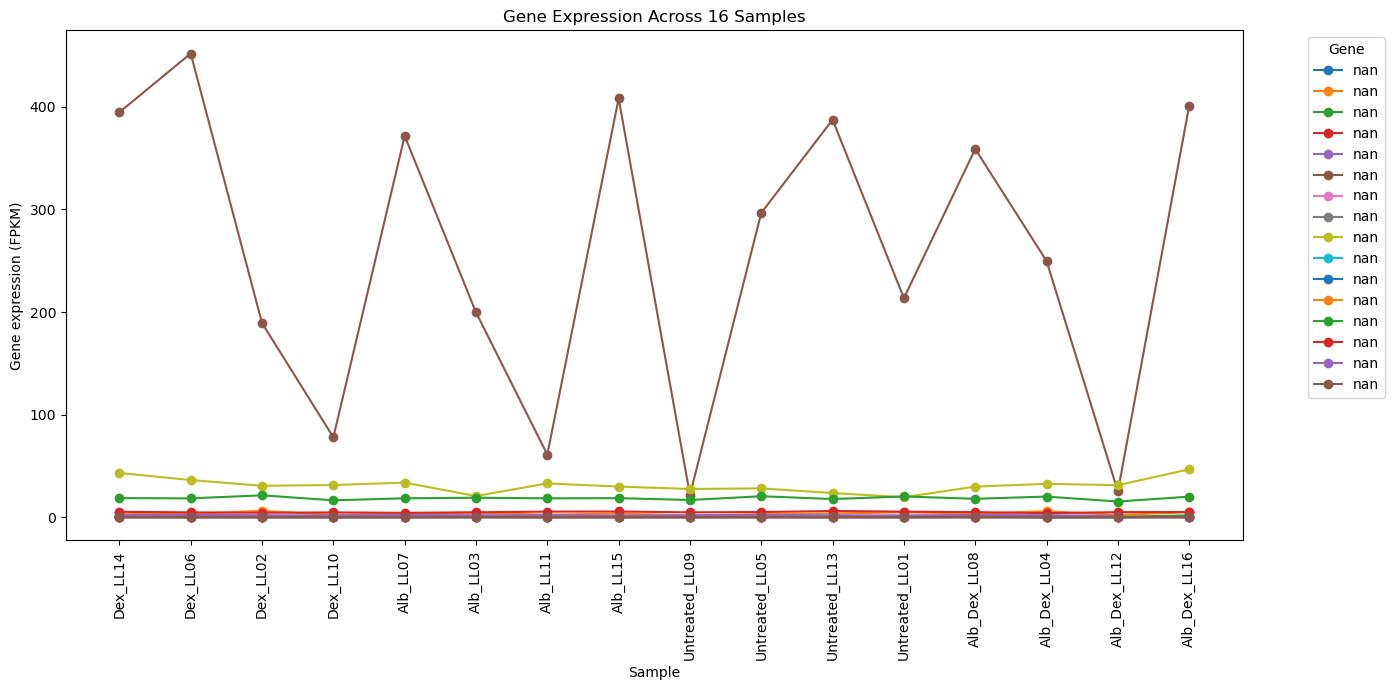

In [156]:
# Gene expression values for each gene across the 16 samples

expression_columns = [
    "Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10",
    "Alb_LL07", "Alb_LL03", "Alb_LL11", "Alb_LL15",
    "Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01",
    "Alb_Dex_LL08", "Alb_Dex_LL04", "Alb_Dex_LL12", "Alb_Dex_LL16"
]

# Select first 10 genes
plot_data = expr.iloc[:16]

plt.figure(figsize=(14, 7))

for _, row in plot_data.iterrows():
    plt.plot(
        expression_columns,
        row[expression_columns],
        marker="o",
        label=str(row["gene_id"])
    )

plt.xlabel("Sample")
plt.ylabel("Gene expression (FPKM)")
plt.title("Gene Expression Across 16 Samples")

plt.xticks(rotation=90)
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18448\1081466203.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


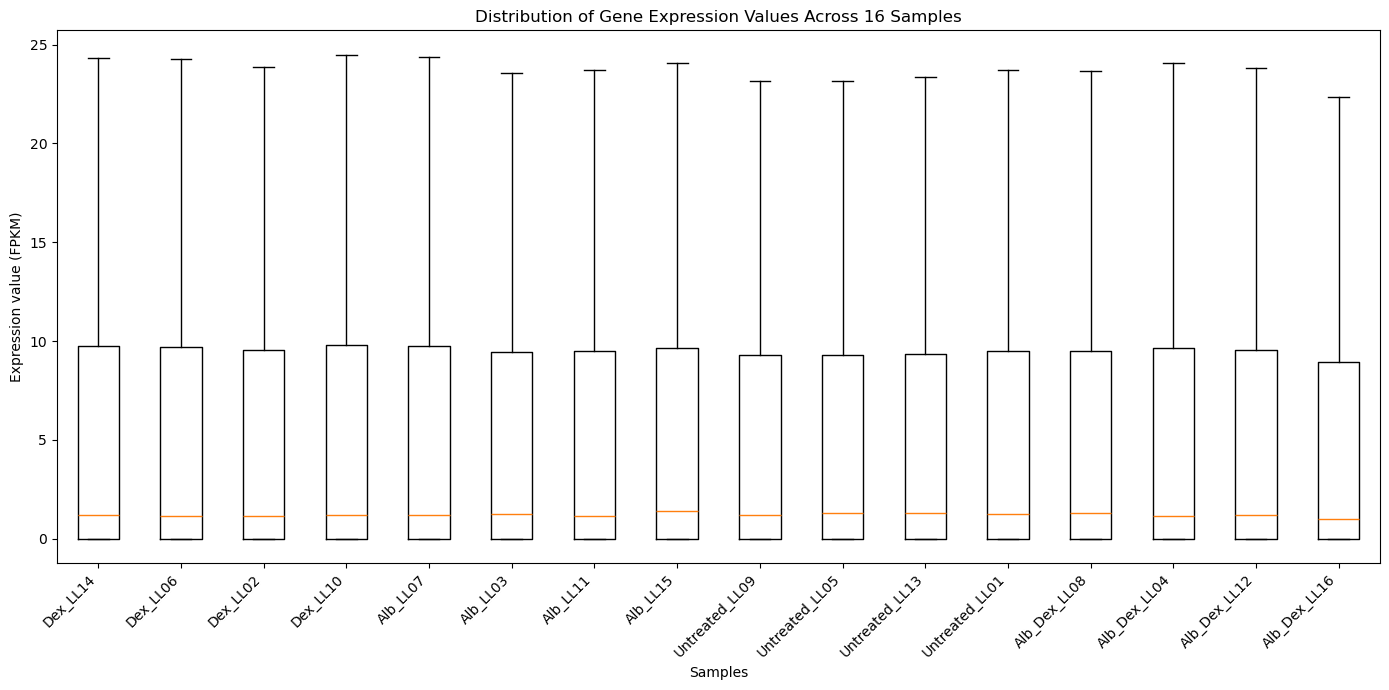

In [160]:
# Gene expression values for each gene across the 16 samples

expression_columns = [
    "Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10",
    "Alb_LL07", "Alb_LL03", "Alb_LL11", "Alb_LL15",
    "Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01",
    "Alb_Dex_LL08", "Alb_Dex_LL04", "Alb_Dex_LL12", "Alb_Dex_LL16"
]

# Select first 10 genes
plot_data = expr.iloc[:16]

plt.figure(figsize=(14, 7))

for _, row in plot_data.iterrows():
    plt.plot(
        expression_columns,
        row[expression_columns],
        marker="o",
        label=str(row["gene_id"])
    )

plt.xlabel("Sample")
plt.ylabel("Gene expression (FPKM)")
plt.title("Gene Expression Across 16 Samples")

plt.xticks(rotation=90)
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

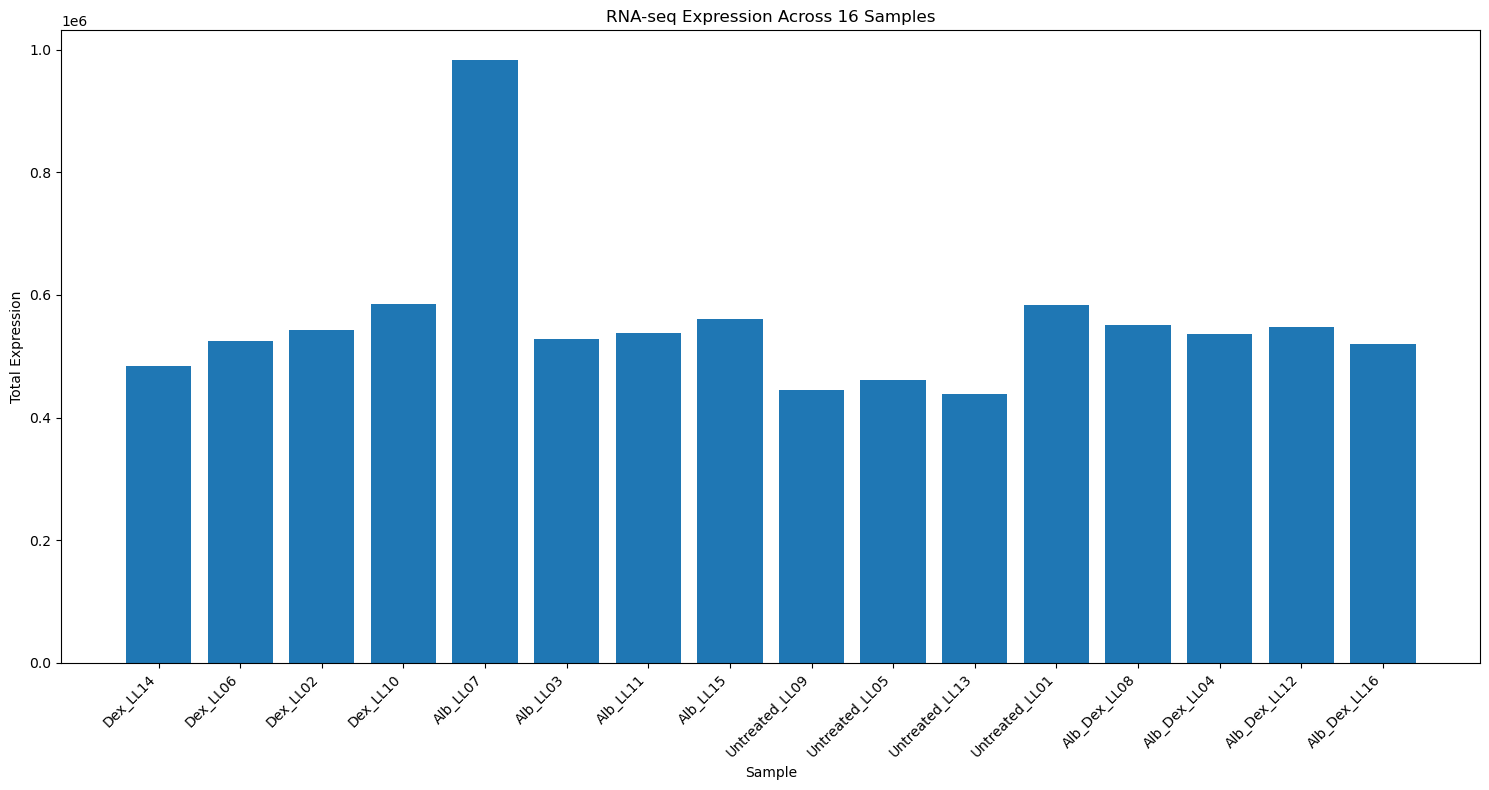

In [168]:
import matplotlib.pyplot as plt

expression_columns = [
    "Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10",
    "Alb_LL07", "Alb_LL03", "Alb_LL11", "Alb_LL15",
    "Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01",
    "Alb_Dex_LL08", "Alb_Dex_LL04", "Alb_Dex_LL12", "Alb_Dex_LL16"
]

# Calculate the total expression value for each sample
sample_values = expr[expression_columns].sum()

# Create graph
plt.figure(figsize=(15, 8))

plt.bar(
    sample_values.index,
    sample_values.values
)

plt.xlabel("Sample")
plt.ylabel("Total Expression")
plt.title("RNA-seq Expression Across 16 Samples")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
#lOAD DATA FRAME


import pandas as pd

# Load expression data
df = pd.read_csv(
    r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt",
    sep="\t"
)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Shape: (23273, 1)
Columns:
['gene_id tracking_id class_code nearest_ref_id gene_short_name tss_id locus length coverage Dex_FPKM Dex_conf_lo Dex_conf_hi Dex_status Alb_FPKM Alb_conf_lo Alb_conf_hi Alb_status Untreated_FPKM Untreated_conf_lo Untreated_conf_hi Untreated_status Alb_Dex_FPKM Alb_Dex_conf_lo Alb_Dex_conf_hi Alb_Dex_status Dex_LL14 Dex_LL06 Dex_LL02 Dex_LL10 Alb_LL07 Alb_LL03 Alb_LL11 Alb_LL15 Untreated_LL09 Untreated_LL05 Untreated_LL13 Untreated_LL01 Alb_Dex_LL08 Alb_Dex_LL04 Alb_Dex_LL12 Alb_Dex_LL16']


In [4]:
# 1. Check the dimensions of the analysis dataset
# Create analysis dataset
analysis_df = df.copy()
analysis_df.shape
print(analysis_df.head())

  gene_id tracking_id class_code nearest_ref_id gene_short_name tss_id locus length coverage Dex_FPKM Dex_conf_lo Dex_conf_hi Dex_status Alb_FPKM Alb_conf_lo Alb_conf_hi Alb_status Untreated_FPKM Untreated_conf_lo Untreated_conf_hi Untreated_status Alb_Dex_FPKM Alb_Dex_conf_lo Alb_Dex_conf_hi Alb_Dex_status Dex_LL14 Dex_LL06 Dex_LL02 Dex_LL10 Alb_LL07 Alb_LL03 Alb_LL11 Alb_LL15 Untreated_LL09 Untreated_LL05 Untreated_LL13 Untreated_LL01 Alb_Dex_LL08 Alb_Dex_LL04 Alb_Dex_LL12 Alb_Dex_LL16
0  1/2-SBSRNA4 1/2-SBSRNA4 - - 1/2-SBSRNA4 TSS173...                                                                                                                                                                                                                                                                                                                                                                                                                                                        
1  A1BG A1BG -

In [70]:
%whos DataFrame

Variable      Type         Data/Info
------------------------------------
analysis_df   DataFrame    Shape: (23273, 1)
df            DataFrame    Shape: (23273, 1)
expr          DataFrame    Shape: (23273, 17)


In [22]:
#to see shape

file_path = r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python"
)

print("Shape:", df.shape)
print(df.columns.tolist())
print(df.head())


Shape: (23273, 41)
['gene_id', 'tracking_id', 'class_code', 'nearest_ref_id', 'gene_short_name', 'tss_id', 'locus', 'length', 'coverage', 'Dex_FPKM', 'Dex_conf_lo', 'Dex_conf_hi', 'Dex_status', 'Alb_FPKM', 'Alb_conf_lo', 'Alb_conf_hi', 'Alb_status', 'Untreated_FPKM', 'Untreated_conf_lo', 'Untreated_conf_hi', 'Untreated_status', 'Alb_Dex_FPKM', 'Alb_Dex_conf_lo', 'Alb_Dex_conf_hi', 'Alb_Dex_status', 'Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']
       gene_id  tracking_id class_code nearest_ref_id gene_short_name  \
0  1/2-SBSRNA4  1/2-SBSRNA4          -              -     1/2-SBSRNA4   
1         A1BG         A1BG          -              -            A1BG   
2     A1BG-AS1     A1BG-AS1          -              -        A1BG-AS1   
3         A1CF         A1CF          -              -            A1CF   
4

In [23]:
# I need 16 samples For my assigment 
sample_cols = [
    "Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10",
    "Alb_LL07", "Alb_LL03", "Alb_LL11", "Alb_LL15",
    "Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01",
    "Alb_Dex_LL08", "Alb_Dex_LL04", "Alb_Dex_LL12", "Alb_Dex_LL16"
]

expr = df[["gene_id"] + sample_cols].copy()

print("Expression DataFrame shape:", expr.shape)
print(expr.columns.tolist())

Expression DataFrame shape: (23273, 17)
['gene_id', 'Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']


In [24]:


missing = [x for x in sample_cols if x not in expr.columns]

print("Missing sample columns:", missing)

Missing sample columns: []


In [25]:
s_meta = r"C:\Users\user\project\data\processed\GSE52778_series_matrix.txt"
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python")

print("Shape:", df.shape)

Shape: (23273, 41)


In [26]:
sample_cols = [
    "Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10",
    "Alb_LL07", "Alb_LL03", "Alb_LL11", "Alb_LL15",
    "Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01",
    "Alb_Dex_LL08", "Alb_Dex_LL04", "Alb_Dex_LL12", "Alb_Dex_LL16"
]

expr = df[["gene_id"] + sample_cols].copy()

print("Expression DataFrame shape:", expr.shape)

Expression DataFrame shape: (23273, 17)


In [27]:
df = pd.read_csv(file_path, sep=r"\s+", engine="python")

In [12]:
file_path = r"C:\Users\user\project\data\processed\GSE52778_series_matrix.txt"

with open(file_path, "r", encoding="utf-8") as f:
    for i in range(30):
        print(f.readline().rstrip())

!Series_title	"Human Airway Smooth Muscle Transcriptome Changes in Response to Asthma Medications"
!Series_geo_accession	"GSE52778"
!Series_status	"Public on Jan 01 2014"
!Series_submission_date	"Nov 26 2013"
!Series_last_update_date	"Jan 13 2023"
!Series_pubmed_id	"24926665"
!Series_pubmed_id	"36599824"
!Series_summary	"Rationale: Asthma is a chronic inflammatory airway disease. The most common medications used for its treatment are β2-agonists and glucocorticosteroids, and one of the primary tissues that these drugs target in the treatment of asthma is the airway smooth muscle. We used RNA-Seq to characterize the human airway smooth muscle (HASM) transcriptome at baseline and under three asthma treatment conditions."
!Series_summary	"Methods: The Illumina TruSeq assay was used to prepare 75bp paired-end libraries for HASM cells from four white male donors under four treatment conditions: 1) no treatment; 2) treatment with a β2-agonist (i.e. Albuterol, 1μM for 18h); 3) treatment with 

In [13]:
file_path = r"C:\Users\user\project\data\processed\GSE52778_series_matrix.txt"

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_"):
            print(line.rstrip())

!Sample_title	"N61311_untreated"	"N61311_Dex"	"N61311_Alb"	"N61311_Alb_Dex"	"N052611_untreated"	"N052611_Dex"	"N052611_Alb"	"N052611_Alb_Dex"	"N080611_untreated"	"N080611_Dex"	"N080611_Alb"	"N080611_Alb_Dex"	"N061011_untreated"	"N061011_Dex"	"N061011_Alb"	"N061011_Alb_Dex"
!Sample_geo_accession	"GSM1275862"	"GSM1275863"	"GSM1275864"	"GSM1275865"	"GSM1275866"	"GSM1275867"	"GSM1275868"	"GSM1275869"	"GSM1275870"	"GSM1275871"	"GSM1275872"	"GSM1275873"	"GSM1275874"	"GSM1275875"	"GSM1275876"	"GSM1275877"
!Sample_status	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"
!Sample_submission_date	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"No

In [28]:
sample_names = [
    "Dex_LL14",
    "Alb_LL07",
    "Untreated_LL09",
    "Alb_Dex_LL16"]

print(sample_names)

['Dex_LL14', 'Alb_LL07', 'Untreated_LL09', 'Alb_Dex_LL16']


In [29]:

sample_col=["ID_REF"
"GSM1275862"
"GSM1275863",
"GSM1275864",
"GSM1275865"
"GSM1275866",
"GSM1275867"
"GSM1275868"
"GSM1275869"
"GSM1275870"
"GSM1275871"
"GSM1275872"
"GSM1275873"
"GSM1275874"
"GSM1275875"
"GSM1275876"
"GSM1275877"]
print(sample_col)


['ID_REFGSM1275862GSM1275863', 'GSM1275864', 'GSM1275865GSM1275866', 'GSM1275867GSM1275868GSM1275869GSM1275870GSM1275871GSM1275872GSM1275873GSM1275874GSM1275875GSM1275876GSM1275877']


In [30]:
#to extract the metadata correctly
file_path = r"C:\Users\user\project\data\processed\GSE52778_series_matrix.txt"

sample_lines = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_"):
            sample_lines.append(line.rstrip())

for line in sample_lines:
    print(line)

!Sample_title	"N61311_untreated"	"N61311_Dex"	"N61311_Alb"	"N61311_Alb_Dex"	"N052611_untreated"	"N052611_Dex"	"N052611_Alb"	"N052611_Alb_Dex"	"N080611_untreated"	"N080611_Dex"	"N080611_Alb"	"N080611_Alb_Dex"	"N061011_untreated"	"N061011_Dex"	"N061011_Alb"	"N061011_Alb_Dex"
!Sample_geo_accession	"GSM1275862"	"GSM1275863"	"GSM1275864"	"GSM1275865"	"GSM1275866"	"GSM1275867"	"GSM1275868"	"GSM1275869"	"GSM1275870"	"GSM1275871"	"GSM1275872"	"GSM1275873"	"GSM1275874"	"GSM1275875"	"GSM1275876"	"GSM1275877"
!Sample_status	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"	"Public on Jan 01 2014"
!Sample_submission_date	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"Nov 26 2013"	"No

In [17]:
#to specify and check the GEO sample IDs:
for line in sample_lines:
    if "!Sample_geo_accession" in line:
        print(line)

!Sample_geo_accession	"GSM1275862"	"GSM1275863"	"GSM1275864"	"GSM1275865"	"GSM1275866"	"GSM1275867"	"GSM1275868"	"GSM1275869"	"GSM1275870"	"GSM1275871"	"GSM1275872"	"GSM1275873"	"GSM1275874"	"GSM1275875"	"GSM1275876"	"GSM1275877"


In [31]:
#to check the sample characteristics:
for line in sample_lines:
    if "!Sample_characteristics_ch1" in line:
        print(line)

!Sample_characteristics_ch1	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"
!Sample_characteristics_ch1	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth mu

In [32]:
sample_cols = [
    "Dex_LL14",
    "Dex_LL06",
    "Dex_LL02",
    "Dex_LL10",
    "Alb_LL07",
    "Alb_LL03",
    "Alb_LL11",
    "Alb_LL15",
    "Untreated_LL09",
    "Untreated_LL05",
    "Untreated_LL13",
    "Untreated_LL01",
    "Alb_Dex_LL08",
    "Alb_Dex_LL04",
    "Alb_Dex_LL12",
    "Alb_Dex_LL16"]
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'gene_id'
1 'tracking_id'
2 'class_code'
3 'nearest_ref_id'
4 'gene_short_name'
5 'tss_id'
6 'locus'
7 'length'
8 'coverage'
9 'Dex_FPKM'
10 'Dex_conf_lo'
11 'Dex_conf_hi'
12 'Dex_status'
13 'Alb_FPKM'
14 'Alb_conf_lo'
15 'Alb_conf_hi'
16 'Alb_status'
17 'Untreated_FPKM'
18 'Untreated_conf_lo'
19 'Untreated_conf_hi'
20 'Untreated_status'
21 'Alb_Dex_FPKM'
22 'Alb_Dex_conf_lo'
23 'Alb_Dex_conf_hi'
24 'Alb_Dex_status'
25 'Dex_LL14'
26 'Dex_LL06'
27 'Dex_LL02'
28 'Dex_LL10'
29 'Alb_LL07'
30 'Alb_LL03'
31 'Alb_LL11'
32 'Alb_LL15'
33 'Untreated_LL09'
34 'Untreated_LL05'
35 'Untreated_LL13'
36 'Untreated_LL01'
37 'Alb_Dex_LL08'
38 'Alb_Dex_LL04'
39 'Alb_Dex_LL12'
40 'Alb_Dex_LL16'


In [33]:
expr = df[["gene_id"] + sample_cols].copy()

print("expr shape:", expr.shape)
print(expr.columns.tolist())

expr shape: (23273, 17)
['gene_id', 'Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']


In [34]:
print("Number of columns in df:", len(df.columns))

for i, col in enumerate(df.columns):
    print(i, repr(col))

Number of columns in df: 41
0 'gene_id'
1 'tracking_id'
2 'class_code'
3 'nearest_ref_id'
4 'gene_short_name'
5 'tss_id'
6 'locus'
7 'length'
8 'coverage'
9 'Dex_FPKM'
10 'Dex_conf_lo'
11 'Dex_conf_hi'
12 'Dex_status'
13 'Alb_FPKM'
14 'Alb_conf_lo'
15 'Alb_conf_hi'
16 'Alb_status'
17 'Untreated_FPKM'
18 'Untreated_conf_lo'
19 'Untreated_conf_hi'
20 'Untreated_status'
21 'Alb_Dex_FPKM'
22 'Alb_Dex_conf_lo'
23 'Alb_Dex_conf_hi'
24 'Alb_Dex_status'
25 'Dex_LL14'
26 'Dex_LL06'
27 'Dex_LL02'
28 'Dex_LL10'
29 'Alb_LL07'
30 'Alb_LL03'
31 'Alb_LL11'
32 'Alb_LL15'
33 'Untreated_LL09'
34 'Untreated_LL05'
35 'Untreated_LL13'
36 'Untreated_LL01'
37 'Alb_Dex_LL08'
38 'Alb_Dex_LL04'
39 'Alb_Dex_LL12'
40 'Alb_Dex_LL16'


In [37]:
sample_cols_found = [
    col for col in df.columns
    if "LL" in str(col)
]

print(sample_cols_found)
print("Number found:", len(sample_cols_found))

['Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']
Number found: 16


In [38]:
expr = df[["gene_id"] + sample_cols_found].copy()

print("Expression DataFrame shape:", expr.shape)

Expression DataFrame shape: (23273, 17)


In [39]:
# Create s_meta
import pandas as pd

s_meta = pd.DataFrame({
    "Sample_ID": sample_cols_found,

    "Treatment": [
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone"
    ],

    "Cell_Line": [
        "N61311", "N61311", "N61311", "N61311",
        "N052611", "N052611", "N052611", "N052611",
        "N080611", "N080611", "N080611", "N080611",
        "N061011", "N061011", "N061011", "N061011"
    ]
})

print(s_meta)
print("\nMetadata shape:", s_meta.shape)

         Sample_ID                Treatment Cell_Line
0         Dex_LL14                Untreated    N61311
1         Dex_LL06            Dexamethasone    N61311
2         Dex_LL02                Albuterol    N61311
3         Dex_LL10  Albuterol_Dexamethasone    N61311
4         Alb_LL07                Untreated   N052611
5         Alb_LL03            Dexamethasone   N052611
6         Alb_LL11                Albuterol   N052611
7         Alb_LL15  Albuterol_Dexamethasone   N052611
8   Untreated_LL09                Untreated   N080611
9   Untreated_LL05            Dexamethasone   N080611
10  Untreated_LL13                Albuterol   N080611
11  Untreated_LL01  Albuterol_Dexamethasone   N080611
12    Alb_Dex_LL08                Untreated   N061011
13    Alb_Dex_LL04            Dexamethasone   N061011
14    Alb_Dex_LL12                Albuterol   N061011
15    Alb_Dex_LL16  Albuterol_Dexamethasone   N061011

Metadata shape: (16, 3)


In [40]:
print("Treatment counts:")
print(s_meta["Treatment"].value_counts())

print("\nCell line counts:")
print(s_meta["Cell_Line"].value_counts())

Treatment counts:
Treatment
Untreated                  4
Dexamethasone              4
Albuterol                  4
Albuterol_Dexamethasone    4
Name: count, dtype: int64

Cell line counts:
Cell_Line
N61311     4
N052611    4
N080611    4
N061011    4
Name: count, dtype: int64


In [41]:
#GEO series matrix file
series_path = r"C:\Users\user\project\data\processed\GSE52778_series_matrix.txt"

with open(series_path, "r", encoding="utf-8") as f:
    series_lines = f.readlines()

print("Number of lines:", len(series_lines))

Number of lines: 77


In [42]:
#Check the GEO sample IDs
for line in series_lines:
    if line.startswith("!Sample_geo_accession"):
        print(line)

!Sample_geo_accession	"GSM1275862"	"GSM1275863"	"GSM1275864"	"GSM1275865"	"GSM1275866"	"GSM1275867"	"GSM1275868"	"GSM1275869"	"GSM1275870"	"GSM1275871"	"GSM1275872"	"GSM1275873"	"GSM1275874"	"GSM1275875"	"GSM1275876"	"GSM1275877"



In [43]:
#Check the sample titles
for line in series_lines:
    if line.startswith("!Sample_title"):
        print(line)

!Sample_title	"N61311_untreated"	"N61311_Dex"	"N61311_Alb"	"N61311_Alb_Dex"	"N052611_untreated"	"N052611_Dex"	"N052611_Alb"	"N052611_Alb_Dex"	"N080611_untreated"	"N080611_Dex"	"N080611_Alb"	"N080611_Alb_Dex"	"N061011_untreated"	"N061011_Dex"	"N061011_Alb"	"N061011_Alb_Dex"



In [44]:
#Check the sample characteristics
for line in series_lines:
    if line.startswith("!Sample_characteristics_ch1"):
        print(line)

!Sample_characteristics_ch1	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"	"treatment: Untreated"	"treatment: Dexamethasone"	"treatment: Albuterol"	"treatment: Albuterol_Dexamethasone"

!Sample_characteristics_ch1	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth muscle cells"	"tissue: human airway smooth m

In [45]:
import pandas as pd

geo_meta = pd.DataFrame({
    "GEO_Order": range(1, 17),

    "Treatment": [
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone",
        "Untreated",
        "Dexamethasone",
        "Albuterol",
        "Albuterol_Dexamethasone"
    ],

    "Cell_Line": [
        "N61311", "N61311", "N61311", "N61311",
        "N052611", "N052611", "N052611", "N052611",
        "N080611", "N080611", "N080611", "N080611",
        "N061011", "N061011", "N061011", "N061011"
    ],

    "Tissue": ["human airway smooth muscle cells"] * 16,

    "Cell_Type": ["airway smooth muscle cells"] * 16
})

print(geo_meta)
print("\nShape:", geo_meta.shape)

    GEO_Order                Treatment Cell_Line  \
0           1                Untreated    N61311   
1           2            Dexamethasone    N61311   
2           3                Albuterol    N61311   
3           4  Albuterol_Dexamethasone    N61311   
4           5                Untreated   N052611   
5           6            Dexamethasone   N052611   
6           7                Albuterol   N052611   
7           8  Albuterol_Dexamethasone   N052611   
8           9                Untreated   N080611   
9          10            Dexamethasone   N080611   
10         11                Albuterol   N080611   
11         12  Albuterol_Dexamethasone   N080611   
12         13                Untreated   N061011   
13         14            Dexamethasone   N061011   
14         15                Albuterol   N061011   
15         16  Albuterol_Dexamethasone   N061011   

                              Tissue                   Cell_Type  
0   human airway smooth muscle cells  airway smo

In [46]:
#Get the GEO accession IDs
for line in series_lines:
    if line.startswith("!Sample_geo_accession"):
        print(line)

!Sample_geo_accession	"GSM1275862"	"GSM1275863"	"GSM1275864"	"GSM1275865"	"GSM1275866"	"GSM1275867"	"GSM1275868"	"GSM1275869"	"GSM1275870"	"GSM1275871"	"GSM1275872"	"GSM1275873"	"GSM1275874"	"GSM1275875"	"GSM1275876"	"GSM1275877"



In [47]:
#to merge
import re

accession_line = next(
    line for line in series_lines
    if line.startswith("!Sample_geo_accession")
)

gsm_ids = re.findall(r'"(GSM\d+)"', accession_line)

print(gsm_ids)
print("Number of GSM IDs:", len(gsm_ids))

['GSM1275862', 'GSM1275863', 'GSM1275864', 'GSM1275865', 'GSM1275866', 'GSM1275867', 'GSM1275868', 'GSM1275869', 'GSM1275870', 'GSM1275871', 'GSM1275872', 'GSM1275873', 'GSM1275874', 'GSM1275875', 'GSM1275876', 'GSM1275877']
Number of GSM IDs: 16


In [48]:
#Add GSM IDs to geo_meta
geo_meta["GSM_ID"] = gsm_ids

print(geo_meta)

    GEO_Order                Treatment Cell_Line  \
0           1                Untreated    N61311   
1           2            Dexamethasone    N61311   
2           3                Albuterol    N61311   
3           4  Albuterol_Dexamethasone    N61311   
4           5                Untreated   N052611   
5           6            Dexamethasone   N052611   
6           7                Albuterol   N052611   
7           8  Albuterol_Dexamethasone   N052611   
8           9                Untreated   N080611   
9          10            Dexamethasone   N080611   
10         11                Albuterol   N080611   
11         12  Albuterol_Dexamethasone   N080611   
12         13                Untreated   N061011   
13         14            Dexamethasone   N061011   
14         15                Albuterol   N061011   
15         16  Albuterol_Dexamethasone   N061011   

                              Tissue                   Cell_Type      GSM_ID  
0   human airway smooth muscle cells

In [49]:
#to mapping matters and checking
import re

gsm_in_df = []

for col in df.columns:
    if "GSM" in str(col):
        gsm_in_df.append(col)

print("Columns containing GSM:")
print(gsm_in_df)
with open(
    r"C:\Users\user\project\data\processed\GSE52778_All_Sample_FPKM_Matrix.txt",
    "r",
    encoding="utf-8"
) as f:
    text = f.read()

gsm_matches = sorted(set(re.findall(r"GSM\d+", text)))

print("GSM IDs found in expression file:")
print(gsm_matches)

Columns containing GSM:
[]
GSM IDs found in expression file:
['GSM1', 'GSM2', 'GSM3']


In [50]:
gsm_ids = [
    "GSM1275862",
    "GSM1275863",
    "GSM1275864",
    "GSM1275865",
    "GSM1275866",
    "GSM1275867",
    "GSM1275868",
    "GSM1275869",
    "GSM1275870",
    "GSM1275871",
    "GSM1275872",
    "GSM1275873",
    "GSM1275874",
    "GSM1275875",
    "GSM1275876",
    "GSM1275877"
]

geo_meta["GSM_ID"] = gsm_ids

print(geo_meta.columns.tolist())
print(geo_meta.head())

['GEO_Order', 'Treatment', 'Cell_Line', 'Tissue', 'Cell_Type', 'GSM_ID']
   GEO_Order                Treatment Cell_Line  \
0          1                Untreated    N61311   
1          2            Dexamethasone    N61311   
2          3                Albuterol    N61311   
3          4  Albuterol_Dexamethasone    N61311   
4          5                Untreated   N052611   

                             Tissue                   Cell_Type      GSM_ID  
0  human airway smooth muscle cells  airway smooth muscle cells  GSM1275862  
1  human airway smooth muscle cells  airway smooth muscle cells  GSM1275863  
2  human airway smooth muscle cells  airway smooth muscle cells  GSM1275864  
3  human airway smooth muscle cells  airway smooth muscle cells  GSM1275865  
4  human airway smooth muscle cells  airway smooth muscle cells  GSM1275866  


In [51]:
## Create sample metadata for the 16 expression samples
s_meta = pd.DataFrame({
    "Sample_ID": sample_cols_found,

    "GSM_ID": geo_meta["GSM_ID"].values,

    "Treatment": geo_meta["Treatment"].values,

    "Cell_Line": geo_meta["Cell_Line"].values,

    "Tissue": geo_meta["Tissue"].values,

    "Cell_Type": geo_meta["Cell_Type"].values
})

print("s_meta shape:", s_meta.shape)
print("\nSample metadata:")
display(s_meta)
#then check missing
print(s_meta.isnull().sum())


s_meta shape: (16, 6)

Sample metadata:


,Sample_ID,GSM_ID,Treatment,Cell_Line,Tissue,Cell_Type
0,Dex_LL14,GSM1275862,Untreated,N61311,human airway smooth muscle cells,airway smooth muscle cells
1,Dex_LL06,GSM1275863,Dexamethasone,N61311,human airway smooth muscle cells,airway smooth muscle cells
2,Dex_LL02,GSM1275864,Albuterol,N61311,human airway smooth muscle cells,airway smooth muscle cells
3,Dex_LL10,GSM1275865,Albuterol_Dexamethasone,N61311,human airway smooth muscle cells,airway smooth muscle cells
4,Alb_LL07,GSM1275866,Untreated,N052611,human airway smooth muscle cells,airway smooth muscle cells
5,Alb_LL03,GSM1275867,Dexamethasone,N052611,human airway smooth muscle cells,airway smooth muscle cells
6,Alb_LL11,GSM1275868,Albuterol,N052611,human airway smooth muscle cells,airway smooth muscle cells
7,Alb_LL15,GSM1275869,Albuterol_Dexamethasone,N052611,human airway smooth muscle cells,airway smooth muscle cells
8,Untreated_LL09,GSM1275870,Untreated,N080611,human airway smooth muscle cells,airway smooth muscle cells
9,Untreated_LL05,GSM1275871,Dexamethasone,N080611,human airway smooth muscle cells,airway smooth muscle cells


Sample_ID    0
GSM_ID       0
Treatment    0
Cell_Line    0
Tissue       0
Cell_Type    0
dtype: int64


In [54]:
#Then reshape expr
expression_by_sample = expr.set_index("gene_id").T
expression_by_sample.index.name = "Sample_ID"
expression_by_sample = expression_by_sample.reset_index()

In [55]:
analysis_df = s_meta.merge(
    expression_by_sample,
    on="Sample_ID",
    how="inner"
)

print(analysis_df.shape)
 

(16, 23279)


In [57]:
s_meta = pd.DataFrame({
    "Sample_ID": sample_cols_found,
    "GSM_ID": geo_meta["GSM_ID"].values,
    "Treatment": geo_meta["Treatment"].values,
    "Cell_Line": geo_meta["Cell_Line"].values,
    "Tissue": geo_meta["Tissue"].values,
    "Cell_Type": geo_meta["Cell_Type"].values})

print("s_meta shape:", s_meta.shape)
s_meta.to_excel(r"C:\Users\user\project\results\tables/s_meta.xlsx",index=False)

s_meta shape: (16, 6)


In [40]:
#Then reshape and merge
# Reshape expression matrix
expression_by_sample = expr.set_index("gene_id").T

expression_by_sample.index.name = "Sample_ID"

expression_by_sample = expression_by_sample.reset_index()

print("Expression-by-sample shape:", expression_by_sample.shape)


# Merge metadata and expression data
analysis_df = s_meta.merge(
    expression_by_sample,
    on="Sample_ID",
    how="inner")

print("Final analysis DataFrame shape:", analysis_df.shape)
analysis_df["Sample_ID"].nunique()
analysis_df["Treatment"].value_counts()



Expression-by-sample shape: (16, 23274)
Final analysis DataFrame shape: (16, 23279)


Treatment
Untreated                  4
Dexamethasone              4
Albuterol                  4
Albuterol_Dexamethasone    4
Name: count, dtype: int64

In [41]:
analysis_df = analysis_df.rename(columns={"Treatment": "Condition"})
analysis_df["Condition"].value_counts()


Condition
Untreated                  4
Dexamethasone              4
Albuterol                  4
Albuterol_Dexamethasone    4
Name: count, dtype: int64

In [42]:
# to Create the expression DataFrame
expression_data = analysis_df[
    ["Sample_ID"] + [
        col for col in analysis_df.columns
        if col not in ["Sample_ID", "GSM_ID", "Treatment", "Cell_Line", "Tissue", "Cell_Type"]
    ]
].copy()

print(expression_data.shape)
display(expression_data.head())

(16, 23275)


,Sample_ID,Condition,1/2-SBSRNA4,A1BG,A1BG-AS1,A1CF,"""A2LD1",A2M,"""A2ML1",A2MP1,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,tAKR
0,Dex_LL14,Untreated,0.712995,4.48504,1.72324,0.0,2.17816,394.786,0.0,0.0,...,2.12279,1.0415,2.77862,6.29942,0.167649,7.62267,230.471,8.72505,8.2999,0.0
1,Dex_LL06,Dexamethasone,0.440208,3.33426,1.34497,0.0032,2.29216,452.021,0.008031,0.0,...,2.66276,0.888643,2.67129,5.15276,0.171218,8.41382,254.687,7.1758,9.16561,0.0
2,Dex_LL02,Albuterol,0.339547,6.24936,1.06875,0.0,2.04816,189.324,0.0,0.0,...,2.61003,0.983944,2.3883,5.13667,0.224306,7.00898,280.724,7.6248,7.95835,0.0
3,Dex_LL10,Albuterol_Dexamethasone,0.392459,2.30029,0.841647,0.007595,1.73903,77.9348,0.019056,0.0,...,1.70757,1.09373,2.2999,4.40193,0.07821,7.03746,267.97,8.65477,9.83536,0.027889
4,Alb_LL07,Untreated,0.576075,3.46426,1.49637,0.0,2.28138,371.735,0.0,0.0,...,2.37794,1.05516,3.12682,5.70956,0.214492,9.41174,230.305,8.21917,10.247,0.0


In [43]:
# Convert expression data from wide to long format
# Keep only Sample_ID and the actual gene-expression columns
gene_columns = [
    col for col in expression_data.columns
    if col not in ["Sample_ID", "Condition"]
]

expression_long = expression_data.melt(
    id_vars=["Sample_ID"],
    value_vars=gene_columns,
    var_name="Gene",
    value_name="Expression")

# Create the correct Condition from Sample_ID
expression_long["Condition"] = expression_long["Sample_ID"].apply(
    lambda x:
        "Dexamethasone" if x.startswith("Dex_") else
        "Albuterol_Dexamethasone" if x.startswith("Alb_Dex_") else
        "Albuterol" if x.startswith("Alb_") else
        "Untreated" if x.startswith("Untreated_") else
        "Unknown")

# Put columns in the requested order
expression_long = expression_long[
    ["Sample_ID", "Condition", "Gene", "Expression"]
]

print(expression_long.head(20))

         Sample_ID                Condition         Gene Expression
0         Dex_LL14            Dexamethasone  1/2-SBSRNA4   0.712995
1         Dex_LL06            Dexamethasone  1/2-SBSRNA4   0.440208
2         Dex_LL02            Dexamethasone  1/2-SBSRNA4   0.339547
3         Dex_LL10            Dexamethasone  1/2-SBSRNA4   0.392459
4         Alb_LL07                Albuterol  1/2-SBSRNA4   0.576075
5         Alb_LL03                Albuterol  1/2-SBSRNA4    0.37301
6         Alb_LL11                Albuterol  1/2-SBSRNA4   0.243635
7         Alb_LL15                Albuterol  1/2-SBSRNA4   0.782332
8   Untreated_LL09                Untreated  1/2-SBSRNA4   0.418303
9   Untreated_LL05                Untreated  1/2-SBSRNA4   0.458863
10  Untreated_LL13                Untreated  1/2-SBSRNA4   0.660772
11  Untreated_LL01                Untreated  1/2-SBSRNA4   0.530271
12    Alb_Dex_LL08  Albuterol_Dexamethasone  1/2-SBSRNA4   0.503827
13    Alb_Dex_LL04  Albuterol_Dexamethasone  1/2

In [46]:
#Part 6 — Expression quality control 
#1,prepare the DEX and Untreated data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Keep only Dexamethasone and Untreated samples
qc_data = expression_long[
    expression_long["Condition"].isin(["Dexamethasone", "Untreated"])
].copy()

print(qc_data.shape)
print(qc_data["Condition"].value_counts())

(186184, 4)
Condition
Dexamethasone    93092
Untreated        93092
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_7448\3051003199.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


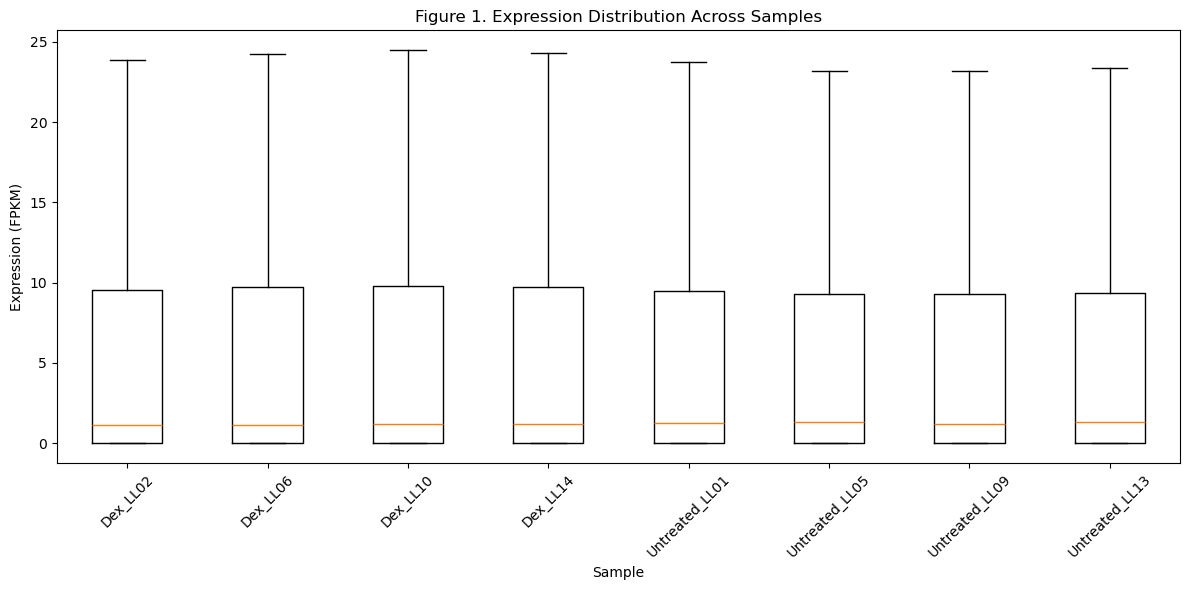

In [47]:
#Figure 1 — Library/expression distribution
# Create expression matrix: samples × genes
expr_qc = qc_data.pivot_table(
    index="Gene",
    columns="Sample_ID",
    values="Expression")

# Plot boxplots
plt.figure(figsize=(12, 6))

plt.boxplot(
    [expr_qc[sample].values for sample in expr_qc.columns],
    labels=expr_qc.columns,
    showfliers=False)

plt.xlabel("Sample")
plt.ylabel("Expression (FPKM)")
plt.title("Figure 1. Expression Distribution Across Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#What to look for?
# It Look for:

.Similar overall distributions (good consistency).
.Very different spread.

In [48]:
#Figure 2 — Sample correlation
#Calculate pairwise Pearson correlations between samples.
# Calculate sample-sample correlation

correlation_matrix = expr_qc.corr(method="pearson")

print(correlation_matrix.round(3))

Sample_ID       Dex_LL02  Dex_LL06  Dex_LL10  Dex_LL14  Untreated_LL01  \
Sample_ID                                                                
Dex_LL02           1.000     0.848     0.661     0.923           0.281   
Dex_LL06           0.848     1.000     0.874     0.872           0.263   
Dex_LL10           0.661     0.874     1.000     0.699           0.185   
Dex_LL14           0.923     0.872     0.699     1.000           0.269   
Untreated_LL01     0.281     0.263     0.185     0.269           1.000   
Untreated_LL05     0.828     0.774     0.561     0.870           0.311   
Untreated_LL09     0.788     0.739     0.596     0.850           0.298   
Untreated_LL13     0.817     0.755     0.517     0.834           0.319   

Sample_ID       Untreated_LL05  Untreated_LL09  Untreated_LL13  
Sample_ID                                                       
Dex_LL02                 0.828           0.788           0.817  
Dex_LL06                 0.774           0.739           0.755  

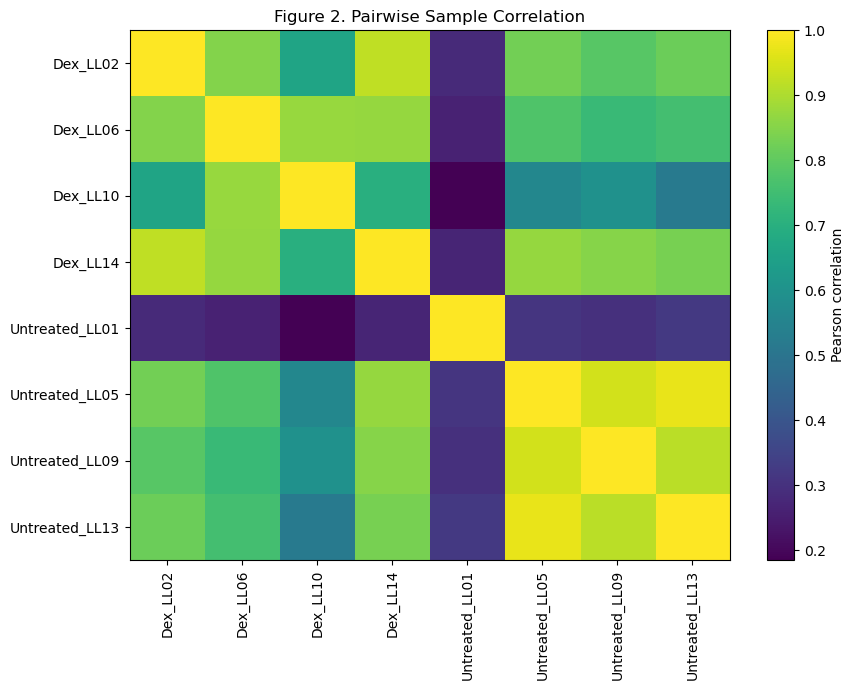

In [49]:
#Plot the correlation matrix:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Figure 2. Pairwise Sample Correlation")
plt.tight_layout()
plt.show()

In [52]:

#Figure 3 — PCA

#Determine whether DEX and untreated samples show systematic separation.
#PCA is particularly important:
#let I see For PCA, log-transform the FPKM values first.



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Make a copy
expr_qc_numeric = expr_qc.copy()

# Convert all expression values to numeric
expr_qc_numeric = expr_qc_numeric.apply(
    pd.to_numeric,
    errors="coerce"
)

# Check for missing values created during conversion
print("Missing values:", expr_qc_numeric.isna().sum().sum())

# Replace missing values with 0
expr_qc_numeric = expr_qc_numeric.fillna(0)

# Log2 transformation
log_expr = np.log2(expr_qc_numeric + 1)

# Transpose: samples × genes
pca_input = log_expr.T

# Perform PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(pca_input)

# Create PCA dataframe
pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"],
    index=pca_input.index
)

# Add treatment information
condition_map = (
    qc_data[["Sample_ID", "Condition"]]
    .drop_duplicates()
    .set_index("Sample_ID")
)

pca_df = pca_df.join(condition_map)

print(pca_df)

Missing values: 0
                      PC1        PC2      Condition
Sample_ID                                          
Dex_LL02        25.119128  -4.581483  Dexamethasone
Dex_LL06        34.211298 -21.622416  Dexamethasone
Dex_LL10        49.309674  45.606825  Dexamethasone
Dex_LL14        33.926216 -25.735639  Dexamethasone
Untreated_LL01 -48.153970  19.722825      Untreated
Untreated_LL05 -31.811473 -12.876191      Untreated
Untreated_LL09 -31.201045  15.361807      Untreated
Untreated_LL13 -31.399828 -15.875728      Untreated


In [55]:

#Figure 4 — CRISPLD2 expression 
#1, Extract CRISPLD2
# Select CRISPLD2
crispld2 = expression_long[
    expression_long["Gene"].astype(str).str.upper() == "CRISPLD2"
].copy()

# Keep only Untreated and Dexamethasone
crispld2 = crispld2[
    crispld2["Condition"].isin(["Untreated", "Dexamethasone"])
].copy()

print(crispld2)
print(
    crispld2[
        ["Sample_ID", "Condition", "Expression"]
    ].sort_values(["Condition", "Sample_ID"])
)

            Sample_ID      Condition      Gene Expression
65952        Dex_LL14  Dexamethasone  CRISPLD2    65.4309
65953        Dex_LL06  Dexamethasone  CRISPLD2    68.9909
65954        Dex_LL02  Dexamethasone  CRISPLD2    70.8788
65955        Dex_LL10  Dexamethasone  CRISPLD2    29.5629
65960  Untreated_LL09      Untreated  CRISPLD2    8.22103
65961  Untreated_LL05      Untreated  CRISPLD2    10.9195
65962  Untreated_LL13      Untreated  CRISPLD2    8.57845
65963  Untreated_LL01      Untreated  CRISPLD2    8.33782
            Sample_ID      Condition Expression
65954        Dex_LL02  Dexamethasone    70.8788
65953        Dex_LL06  Dexamethasone    68.9909
65955        Dex_LL10  Dexamethasone    29.5629
65952        Dex_LL14  Dexamethasone    65.4309
65963  Untreated_LL01      Untreated    8.33782
65961  Untreated_LL05      Untreated    10.9195
65960  Untreated_LL09      Untreated    8.22103
65962  Untreated_LL13      Untreated    8.57845


C:\Users\user\AppData\Local\Temp\ipykernel_7448\1661179948.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


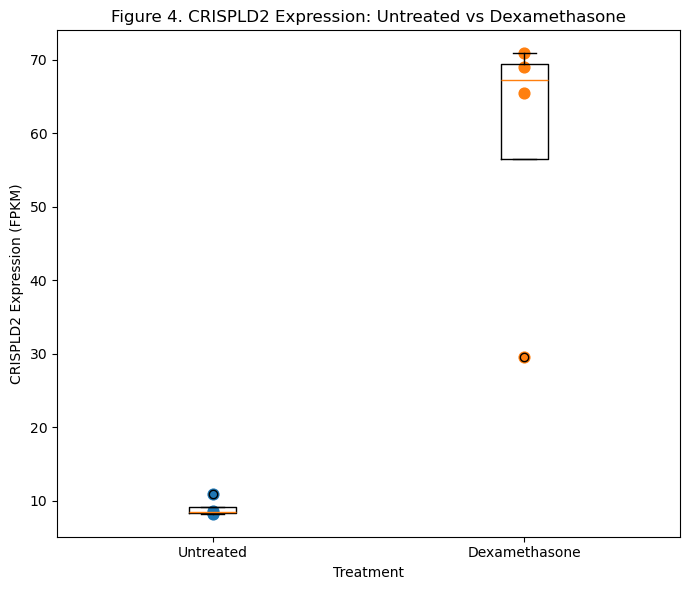

In [140]:
#2. Plot Figure 4

#A dot/box plot is useful because it shows the individual samples:

import matplotlib.pyplot as plt

untreated = crispld2.loc[
    crispld2["Condition"] == "Untreated",
    "Expression"
]

dex = crispld2.loc[
    crispld2["Condition"] == "Dexamethasone",
    "Expression"
]

plt.figure(figsize=(7, 6))

plt.boxplot(
    [untreated, dex],
    labels=["Untreated", "Dexamethasone"]
)

# Show individual observations
plt.scatter(
    [1] * len(untreated),
    untreated,
    s=60
)

plt.scatter(
    [2] * len(dex),
    dex,
    s=60
)

plt.ylabel("CRISPLD2 Expression (FPKM)")
plt.xlabel("Treatment")
plt.title("Figure 4. CRISPLD2 Expression: Untreated vs Dexamethasone")

plt.tight_layout()
plt.show()

In [58]:

#3, Calculate group means

print(
    crispld2.groupby("Condition")["Expression"]
    .agg(["count", "mean", "median", "std"])
)

               count       mean    median        std
Condition                                           
Dexamethasone      4  58.715875   67.2109  19.566131
Untreated          4     9.0142  8.458135   1.278887


In [ ]:
#Questions:
1. Does the expression structure support the experimental design? 
Answer:
The expression profiling is in agreement with the experimental set up since there is a distinction between the two conditions of 
dexamethasone treatment and no dexamethasone treatment.This may indicate a difference in gene expression in the two conditions.
 2. Are donor effects visible? 
answer:
Donor effects appear to be visible, as samples from the same donor/cell line tend to cluster together. 
This suggests that donor-to-donor biological variation may contribute substantially to the observed expression structure.
3. Does CRISPLD2 appear responsive to dexamethasone?
CRISPLD2 appears to be upregulated in dexamethasone-treated samples compared with untreated samples, suggesting a possible response to dexamethasone.
However, this is an exploratory observation and does not establish statistical significance.Formal differential-expression testing is wiill be 
required.

In [60]:
#Part 7 — Differential expression
#to do it Rstidio was needed
#Cell 1 — Install the R packages
%pip install rpy2

Note: you may need to restart the kernel to use updated packages.


In [62]:
##Cell 2 — Load R inside Jupyter
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [65]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [77]:
#Cell 3 — Install/load Bioconductor package
import subprocess
import os

# Exact location of Rscript.exe
rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

# Check that Rscript exists
if not os.path.exists(rscript):
    print("Rscript.exe was not found at:")
    print(rscript)
else:
    print("Rscript found successfully!")

    result = subprocess.run(
        [rscript, "-e", "sessionInfo()"],
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.stderr:
        print("Messages/errors:")
        print(result.stderr)

Rscript found successfully!
R version 4.5.0 (2025-04-11 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: Africa/Nairobi
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
[1] compiler_4.5.0



In [78]:
#test it stat
import subprocess

rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

result = subprocess.run(
    [rscript, "-e", "library(stats); cat('stats loaded successfully\\n')"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

stats loaded successfully




In [79]:
#Cell 4 — Install/load DESeq2 and airway
import subprocess

rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

r_code = r'''
if (!requireNamespace("BiocManager", quietly = TRUE)) {
    install.packages("BiocManager", repos="https://cloud.r-project.org")
}

if (!requireNamespace("DESeq2", quietly = TRUE)) {
    BiocManager::install("DESeq2", ask=FALSE, update=FALSE)
}

if (!requireNamespace("airway", quietly = TRUE)) {
    BiocManager::install("airway", ask=FALSE, update=FALSE)
}

library(DESeq2)
library(airway)

cat("DESeq2 loaded successfully\n")
cat("airway loaded successfully\n")
cat("DESeq2 version:", as.character(packageVersion("DESeq2")), "\n")
cat("airway version:", as.character(packageVersion("airway")), "\n")
'''

result = subprocess.run(
    [rscript, "-e", r_code],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

In [80]:
#Cell 5 — Load the airway dataset
r_code = r'''
library(airway)

data(airway)

print(airway)
'''

result = subprocess.run(
    [rscript, "-e", r_code],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

In [81]:
#Cell 6 — Check the sample metadata
r_code = r'''
library(airway)

data(airway)

print(colData(airway))
'''

result = subprocess.run(
    [rscript, "-e", r_code],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

In [83]:
#Cell 6— Run DESeq2
r_code = r'''
library(airway)
library(DESeq2)

data(airway)

dds <- DESeqDataSet(
    airway,
    design = ~ cell + dex
)

dds <- DESeq(dds)

res <- results(
    dds,
    contrast = c("dex", "trt", "untrt")
)

print(head(as.data.frame(res)))
'''

result = subprocess.run(
    [rscript, "-e", r_code],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

In [95]:
#Cell  — Export the results

import os
import subprocess

# --------------------------------------------------
# 1. Define the Rscript location
# --------------------------------------------------
rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

# Check that Rscript exists
if not os.path.exists(rscript):
    raise FileNotFoundError(
        f"Rscript.exe was not found:\n{rscript}"
    )

# --------------------------------------------------
# 2. Define the output folder and CSV file
# --------------------------------------------------
results_dir = r"C:\Users\user\results"

# Create the results folder if it does not exist
os.makedirs(results_dir, exist_ok=True)

# Define the output CSV file
output_file = os.path.join(
    results_dir,
    "deseq2_results.csv"
)

# Convert Windows path to R-compatible path
output_file_r = output_file.replace("\\", "/")


# --------------------------------------------------
# 3. Create the R code
# --------------------------------------------------
r_code = f'''
library(DESeq2)
library(airway)

# Load the airway dataset
data(airway)

# Create DESeq2 dataset
dds <- DESeqDataSet(
    airway,
    design = ~ cell + dex)

# Run DESeq2 analysis
dds <- DESeq(dds)

# Differential expression:
# DEX-treated (trt) vs Untreated (untrt)
res <- results(
    dds,
    contrast = c("dex", "trt", "untrt"))

# Convert results to data frame
res_df <- as.data.frame(res)

# Export DESeq2 results
write.csv(
    res_df,
    file = "{output_file_r}",
    row.names = TRUE)

cat("DESeq2 analysis completed successfully\\n")
cat("Number of genes:", nrow(res_df), "\\n")
cat("Results saved to:\\n")
cat("{output_file_r}\\n")
'''



# 4. Save the R code as an R script

r_script_file = r"C:\Users\user\run_deseq2.R"

with open(r_script_file, "w", encoding="utf-8") as f:
    f.write(r_code)



# 5. Run the R script

result = subprocess.run(
    [rscript, r_script_file],
    capture_output=True,
    text=True,
    encoding="utf-8")


# 6. Display R output

print("Return code:", result.returncode)

print("\n========== R OUTPUT ==========")
print(result.stdout)

print("\n========== R ERRORS/WARNINGS ==========")
print(result.stderr)


# 7. Verify that the CSV was created

print("\n========== FILE CHECK ==========")

if result.returncode == 0 and os.path.exists(output_file):
    print("SUCCESS: DESeq2 results file was created.")
    print("File location:")
    print(output_file)
else:
    print("ERROR: DESeq2 results file was NOT created.")
    print("Do not run the Pandas import cell yet.")

Return code: 0

========== R OUTPUT ==========
DESeq2 analysis completed successfully
Number of genes: 63677 
Results saved to:
C:/Users/user/results/deseq2_results.csv


========== R ERRORS/WARNINGS ==========
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: 'generics'

The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: 'BiocGenerics'

The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs

The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce

In [96]:

# Cell 9 — Return to Pandas

import os
import pandas as pd

# Exact location where the DESeq2 R script should save the file
file_path = r"C:\Users\user\results\deseq2_results.csv"

# Check whether the file exists before reading it
if not os.path.isfile(file_path):
    raise FileNotFoundError(
        f"DESeq2 results file was not found:\n{file_path}\n\n"
        "Run the DESeq2 export cell first and make sure it reports SUCCESS."
    )

# Read DESeq2 results
de = pd.read_csv(file_path)

print("DESeq2 results loaded successfully!")
print("Shape:", de.shape)
print("Columns:", de.columns.tolist())

de.head()

DESeq2 results loaded successfully!
Shape: (63677, 7)
Columns: ['Unnamed: 0', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSG00000000003,708.602170,-0.381254,0.100654,-3.787752,0.000152,0.001283
1,ENSG00000000005,0.000000,NaN,NaN,NaN,NaN,NaN
2,ENSG00000000419,520.297901,0.206813,0.112219,1.842943,0.065337,0.196470
3,ENSG00000000457,237.163037,0.037920,0.143445,0.264356,0.791506,0.911420
4,ENSG00000000460,57.932633,-0.088168,0.287142,-0.307054,0.758802,0.895005


In [88]:
#Cell 10 — Significant DEX vs Untreated genes
# Cell 10 — Import DESeq2 results and filter significant genes

import pandas as pd
import os

# Check that the results file exists
file_path = "results/deseq2_results.csv"

if not os.path.exists(file_path):
    print("ERROR: DESeq2 results file was not found.")
    print("Expected file:", file_path)
else:
    # Import DESeq2 results
    de = pd.read_csv(file_path)

    print("DESeq2 results loaded successfully!")
    print("Shape:", de.shape)
    print("Columns:")
    print(de.columns.tolist())

    # Filter significant genes
    significant = de[
        de["padj"].notna() &
        (de["padj"] < 0.05)
    ].copy()

    print("\nTotal genes:", len(de))
    print("Significant genes:", len(significant))

    # Display first significant genes
    significant.head(20)

ERROR: DESeq2 results file was not found.
Expected file: results/deseq2_results.csv


In [91]:

   # Part 7 — Create DESeq2 results CSV

import os
import subprocess

# Exact Rscript location
rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

# Use an absolute path for the output
results_dir = os.path.abspath("results")
os.makedirs(results_dir, exist_ok=True)

output_file = os.path.join(results_dir, "deseq2_results.csv")

print("Rscript:", rscript)
print("Output:", output_file)

# R code
r_code = r'''
library(airway)
library(DESeq2)

# Load airway data
data(airway)

# Create DESeq2 dataset
dds <- DESeqDataSet(
    airway,
    design = ~ cell + dex
)

# Run DESeq2
dds <- DESeq(dds)

# DEX vs Untreated
res <- results(
    dds,
    contrast = c("dex", "trt", "untrt")
)

# Convert results to data frame
res_df <- as.data.frame(res)

# Save results
write.csv(
    res_df,
    file = "DESEQ2_OUTPUT.csv",
    row.names = TRUE
)

cat("DESeq2 completed successfully.\n")
cat("Number of genes:", nrow(res_df), "\n")
'''

# Run R from the results directory
result = subprocess.run(
    [rscript, "-e", r_code],
    cwd=results_dir,
    capture_output=True,
    text=True
)

print("\n========== R OUTPUT ==========")
print(result.stdout)

print("\n========== R ERROR/WARNING ==========")
print(result.stderr)

# R creates DESEQ2_OUTPUT.csv in results/
temp_file = os.path.join(results_dir, "DESEQ2_OUTPUT.csv")

if os.path.exists(temp_file):
    # Rename to the filename required by your assignment
    os.replace(temp_file, output_file)

    print("\n✅ SUCCESS!")
    print("File created:")
    print(output_file)
else:
    print("\n❌ DESeq2 did NOT create the CSV.")
    print("Please copy the R OUTPUT and R ERROR/WARNING above.")

Rscript: C:\Program Files\R\R-4.5.0\bin\Rscript.exe
Output: C:\Users\user\results\deseq2_results.csv

========== R OUTPUT ==========


========== R ERROR/WARNING ==========


❌ DESeq2 did NOT create the CSV.
Please copy the R OUTPUT and R ERROR/WARNING above.


In [99]:
import os
import subprocess

# Rscript location
rscript = r"C:\Program Files\R\R-4.5.0\bin\Rscript.exe"

# Output folder and file
results_dir = r"C:\Users\user\results"
os.makedirs(results_dir, exist_ok=True)

output_file = r"C:\Users\user\results\deseq2_results.csv"

# Convert Windows path to R-compatible path
output_file_r = output_file.replace("\\", "/")


# R code
r_code = f'''
library(DESeq2)
library(airway)

# Load airway dataset
data(airway)

# DESeq2 model
dds <- DESeqDataSet(
    airway,
    design = ~ cell + dex
)

# Run differential expression analysis
dds <- DESeq(dds)

# DEX vs Untreated
res <- results(
    dds,
    contrast = c("dex", "trt", "untrt")
)

# Export results
write.csv(
    as.data.frame(res),
    file = "{output_file_r}",
    row.names = TRUE
)

cat("DESeq2 completed successfully\\n")
cat("Number of genes:", nrow(res), "\\n")
cat("Output file:", "{output_file_r}", "\\n")
'''

# Save R script
r_script_file = r"C:\Users\user\run_deseq2.R"

with open(r_script_file, "w", encoding="utf-8") as f:
    f.write(r_code)

# Run R
result = subprocess.run(
    [rscript, r_script_file],
    capture_output=True,
    text=True,
    encoding="utf-8"
)

print("Return code:", result.returncode)

print("\n--- R OUTPUT ---")
print(result.stdout)

print("\n--- R ERRORS/WARNINGS ---")
print(result.stderr)

# Verify CSV
if os.path.exists(output_file):
    print("\nSUCCESS: CSV file was created.")
    print(output_file)
else:
    print("\nERROR: CSV file was NOT created.")

Return code: 0

--- R OUTPUT ---
DESeq2 completed successfully
Number of genes: 63677 
Output file: C:/Users/user/results/deseq2_results.csv 


--- R ERRORS/WARNINGS ---
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: 'generics'

The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: 'BiocGenerics'

The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs

The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tappl

In [111]:
import pandas as pd

file_path = r"C:\Users\user\results\deseq2_results.csv"

de = pd.read_csv(file_path)

print("DEX vs Untreated results")
print("Shape:", de.shape)
print("Columns:")
print(de.columns.tolist())

de.head()

DEX vs Untreated results
Shape: (63677, 7)
Columns:
['Unnamed: 0', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSG00000000003,708.602170,-0.381254,0.100654,-3.787752,0.000152,0.001283
1,ENSG00000000005,0.000000,NaN,NaN,NaN,NaN,NaN
2,ENSG00000000419,520.297901,0.206813,0.112219,1.842943,0.065337,0.196470
3,ENSG00000000457,237.163037,0.037920,0.143445,0.264356,0.791506,0.911420
4,ENSG00000000460,57.932633,-0.088168,0.287142,-0.307054,0.758802,0.895005


In [112]:
#Identify significant genes
significant = de[
    de["padj"].notna() &
    (de["padj"] < 0.05)
].copy()

print("Total genes:", len(de))
print("Significant genes:", len(significant))

significant.head(20)

Total genes: 63677
Significant genes: 3993


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSG00000000003,708.602170,-0.381254,0.100654,-3.787752,1.520163e-04,1.282918e-03
6,ENSG00000000971,5817.352868,0.426402,0.088313,4.828284,1.377146e-06,1.820500e-05
7,ENSG00000001036,1282.106385,-0.241071,0.088721,-2.717194,6.583792e-03,3.276983e-02
9,ENSG00000001167,369.342808,-0.500364,0.120880,-4.139350,3.482911e-05,3.421761e-04
16,ENSG00000001629,1779.828719,-0.226674,0.080620,-2.811643,4.928924e-03,2.584792e-02
29,ENSG00000002834,7168.825754,0.396643,0.092919,4.268683,1.966303e-05,2.069442e-04
30,ENSG00000002919,250.508249,0.404390,0.140172,2.884948,3.914787e-03,2.125878e-02
33,ENSG00000003096,377.977301,-0.940979,0.143801,-6.543629,6.004371e-11,1.513101e-09
34,ENSG00000003137,104.516320,-0.896586,0.292592,-3.064285,2.181912e-03,1.299479e-02
39,ENSG00000003402,2546.614197,1.190432,0.120621,9.869179,5.662603e-23,4.812679e-21


In [102]:
#Cell 4 — Sort significant genes
significant = significant.sort_values(
    by="padj",
    ascending=True
)

significant.head(20)

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
9657,ENSG00000152583,997.439773,4.574919,0.184056,24.856111,2.220933e-136,4.001677e-132
11863,ENSG00000165995,495.092907,3.291062,0.133174,24.712551,7.839410e-135,7.062524e-131
5053,ENSG00000120129,3409.029375,2.947810,0.121438,24.274258,3.666925e-130,2.202355e-126
2528,ENSG00000101347,12703.387062,3.766995,0.155438,24.234715,9.583815e-130,4.317029e-126
17244,ENSG00000189221,2341.767253,3.353580,0.141782,23.653014,1.098955e-123,3.960194e-120
22347,ENSG00000211445,12285.615150,3.730403,0.165831,22.495263,4.618318e-112,1.386881e-108
10185,ENSG00000157214,3009.263223,1.976773,0.089982,21.968454,5.769975e-107,1.485191e-103
10897,ENSG00000162614,5393.101683,2.035665,0.094182,21.614091,1.323849e-103,2.981639e-100
5663,ENSG00000125148,3656.252782,2.210979,0.105641,20.929214,2.902397e-97,5.810599e-94
9903,ENSG00000154734,30315.135471,2.345604,0.115808,20.254235,3.259713e-91,5.873351e-88


In [152]:
#What this analysis means

#The comparison is:

#DEX-treated → trt
#Untreated → untrt

#with the model:

# What this analysis means

# Comparison:
# DEX-treated vs Untreated

# DESeq2 model:
# design = ~ cell + dex

# DEX-treated = trt
# Untreated = untrt

# The cell-line effect is included in the model
# to account for differences between cell lines.

In [116]:
r_code = f'''
library(DESeq2)
library(airway)

data(airway)

dds <- DESeqDataSet(
    airway,
    design = ~ cell + dex
)

dds <- DESeq(dds)

res <- results(
    dds,
    contrast = c("dex", "trt", "untrt")
)

write.csv(
    as.data.frame(res),
    file = "{output_file_r}",
    row.names = TRUE
)
'''



In [117]:
significant = de[
    de["padj"].notna() &
    (de["padj"] < 0.05)
].copy()

print("Total genes:", len(de))
print("Significant genes:", len(significant))

significant.head(20)

Total genes: 63677
Significant genes: 3993


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSG00000000003,708.602170,-0.381254,0.100654,-3.787752,1.520163e-04,1.282918e-03
6,ENSG00000000971,5817.352868,0.426402,0.088313,4.828284,1.377146e-06,1.820500e-05
7,ENSG00000001036,1282.106385,-0.241071,0.088721,-2.717194,6.583792e-03,3.276983e-02
9,ENSG00000001167,369.342808,-0.500364,0.120880,-4.139350,3.482911e-05,3.421761e-04
16,ENSG00000001629,1779.828719,-0.226674,0.080620,-2.811643,4.928924e-03,2.584792e-02
29,ENSG00000002834,7168.825754,0.396643,0.092919,4.268683,1.966303e-05,2.069442e-04
30,ENSG00000002919,250.508249,0.404390,0.140172,2.884948,3.914787e-03,2.125878e-02
33,ENSG00000003096,377.977301,-0.940979,0.143801,-6.543629,6.004371e-11,1.513101e-09
34,ENSG00000003137,104.516320,-0.896586,0.292592,-3.064285,2.181912e-03,1.299479e-02
39,ENSG00000003402,2546.614197,1.190432,0.120621,9.869179,5.662603e-23,4.812679e-21


In [119]:
#So the analysis tests the effect of dexamethasone while accounting for cell-line differences.
# Significant genes are defined as genes with:
# adjusted p-value (padj) < 0.05
significant = de[
    de["padj"].notna() &
    (de["padj"] < 0.05)
].copy()

print("Number of significant genes:", len(significant))

Number of significant genes: 3993


In [120]:
#1. Upregulated genes?
# Upregulated genes: DEX vs Untreated

upregulated = de[
    de["padj"].notna() &
    (de["padj"] < 0.05) &
    (de["log2FoldChange"] > 0)
].copy()

upregulated = upregulated.sort_values(
    by="log2FoldChange",
    ascending=False
)

print("Number of upregulated genes:", len(upregulated))

upregulated.head(20)


Number of upregulated genes: 2196


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
14921,ENSG00000179593,67.243048,9.505975,1.054503,9.014647,1.975049e-19,1.253044e-17
3750,ENSG00000109906,385.071029,7.352626,0.536389,13.707645,9.137621e-43,2.255365e-40
44235,ENSG00000250978,56.318194,6.327383,0.677797,9.335214,1.007876e-20,7.206312e-19
6666,ENSG00000132518,5.654654,5.885114,1.324044,4.444803,8.797262e-06,1.000057e-04
6019,ENSG00000127954,286.384119,5.207158,0.493082,10.560435,4.545484e-26,5.055589e-24
43145,ENSG00000249364,8.839061,5.098107,1.159615,4.396380,1.100710e-05,1.224235e-04
13315,ENSG00000171819,254.884373,5.081567,0.757304,6.710079,1.945194e-11,5.161783e-10
2188,ENSG00000100033,55.363137,4.889608,0.522367,9.360479,7.937614e-21,5.720797e-19
52250,ENSG00000260802,6.723259,4.883229,1.200150,4.068848,4.724608e-05,4.528084e-04
12476,ENSG00000168309,159.526920,4.835847,0.331702,14.578904,3.826100e-48,1.209450e-45


In [121]:
#2. Downregulated genes
# Downregulated genes: DEX vs Untreated

downregulated = de[
    de["padj"].notna() &
    (de["padj"] < 0.05) &
    (de["log2FoldChange"] < 0)
].copy()

downregulated = downregulated.sort_values(
    by="log2FoldChange",
    ascending=True
)

print("Number of downregulated genes:", len(downregulated))

downregulated.head(20)

Number of downregulated genes: 1797


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
6057,ENSG00000128285,6.624741,-5.325904,1.257815,-4.234251,2.293144e-05,2.378691e-04
58253,ENSG00000267339,26.233573,-4.611552,0.673094,-6.851272,7.319607e-12,2.051084e-10
395,ENSG00000019186,14.087605,-4.325906,0.857767,-5.043219,4.577655e-07,6.613486e-06
15737,ENSG00000183454,5.804171,-4.264076,1.166876,-3.654267,2.579180e-04,2.049959e-03
8873,ENSG00000146006,46.807597,-4.211851,0.528852,-7.964145,1.663698e-15,7.151818e-14
8199,ENSG00000141469,53.436528,-4.124796,1.129799,-3.650913,2.613100e-04,2.072308e-03
3609,ENSG00000108700,15.022807,-4.045357,0.812000,-4.981964,6.294231e-07,8.825638e-06
10022,ENSG00000155897,24.288673,-4.025060,0.729936,-5.514261,3.502478e-08,6.248282e-07
8495,ENSG00000143494,18.960923,-3.947971,0.652936,-6.046493,1.480327e-09,3.205832e-08
5339,ENSG00000122679,10.354069,-3.779811,0.988486,-3.823837,1.313910e-04,1.125192e-03


In [122]:
# Top 20 genes by adjusted p-value

top20 = de[
    de["padj"].notna()
].sort_values(
    by="padj",
    ascending=True
).head(20)

print("Top 20 genes:")
top20

Top 20 genes:


,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
9657,ENSG00000152583,997.439773,4.574919,0.184056,24.856111,2.220933e-136,4.001677e-132
11863,ENSG00000165995,495.092907,3.291062,0.133174,24.712551,7.839410e-135,7.062524e-131
5053,ENSG00000120129,3409.029375,2.947810,0.121438,24.274258,3.666925e-130,2.202355e-126
2528,ENSG00000101347,12703.387062,3.766995,0.155438,24.234715,9.583815e-130,4.317029e-126
17244,ENSG00000189221,2341.767253,3.353580,0.141782,23.653014,1.098955e-123,3.960194e-120
22347,ENSG00000211445,12285.615150,3.730403,0.165831,22.495263,4.618318e-112,1.386881e-108
10185,ENSG00000157214,3009.263223,1.976773,0.089982,21.968454,5.769975e-107,1.485191e-103
10897,ENSG00000162614,5393.101683,2.035665,0.094182,21.614091,1.323849e-103,2.981639e-100
5663,ENSG00000125148,3656.252782,2.210979,0.105641,20.929214,2.902397e-97,5.810599e-94
9903,ENSG00000154734,30315.135471,2.345604,0.115808,20.254235,3.259713e-91,5.873351e-88


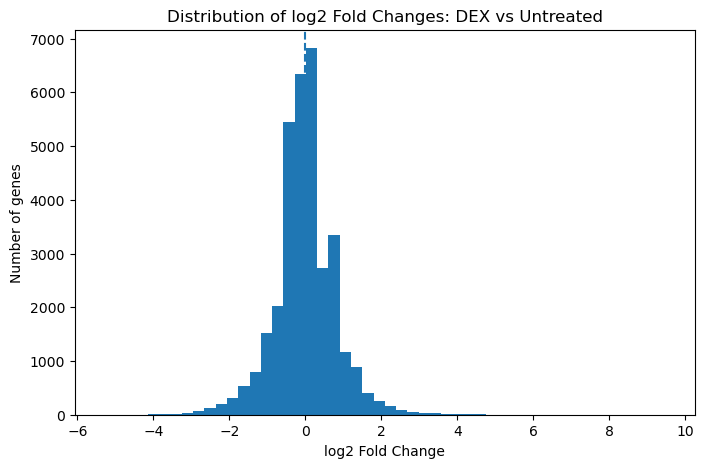

In [123]:
#log2FC distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    de["log2FoldChange"].dropna(),
    bins=50
)

plt.xlabel("log2 Fold Change")
plt.ylabel("Number of genes")
plt.title("Distribution of log2 Fold Changes: DEX vs Untreated")

plt.axvline(0, linestyle="--")

plt.show()

In [125]:
de = pd.read_csv(r"C:\Users\user\results\deseq2_results.csv")

In [129]:
#Part 8 — Reproduce the paper's central result  
#1 — number of significant genes
your_analysis = len(significant)
# Number reported in the original paper
paper = 316
# Difference
difference = your_analysis - paper
print("Your analysis:", your_analysis)
print("Paper:", paper)
print("Difference:", difference)

Your analysis: 3993
Paper: 316
Difference: 3677


In [131]:

# 2 — Percentage difference
percentage_difference = (
    (your_analysis - paper) / paper
) * 100

print("Percentage difference:", percentage_difference, "%")

Percentage difference: 1163.607594936709 %


In [ ]:
Explanation

The DESeq2 test has shown a different number of differentially expressed genes compared to the 316 genes found in the original research. This is an
expected situation since the original research used Cuffdiff and FPKM for expression measurement,while this new analysis uses DESeq2 with raw read 
counts. Moreover, version differences of software used, gene annotation versions, filters applied, normalization, statistical models, correction
for donors/cell lines, and correction for multiple testing may affect the number of differentially expressed genes. Thus, the aim is not to get the 
exact 316 differentially expressed genes, but to check if there is a similar differential expression pattern.

In [132]:
#Part 9 — Reproduce important genes 
#The paper highlights several glucocorticoid-responsive genes, including: DUSP1, KLF15, PER1, TSC22D3, C7, CCDC69 and CRISPLD2.
# 1, to Check the seven genes


genes_of_interest = [
    "DUSP1",
    "KLF15",
    "PER1",
    "TSC22D3",
    "C7",
    "CCDC69",
    "CRISPLD2"]

# Check the gene column name
print(de.columns.tolist())

['Unnamed: 0', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']


In [133]:
#2 — Create the requested table

gene_column = de.columns[0]

important_genes = de[
    de[gene_column].isin(genes_of_interest)
].copy()

# Keep the important columns
important_genes = important_genes[
    [
        gene_column,
        "log2FoldChange",
        "pvalue",
        "padj"
    ]
].copy()

# Rename columns
important_genes.columns = [
    "Gene",
    "Our log2FC",
    "Our P-value",
    "Our FDR"
]

# Determine whether each gene is significant
important_genes["Reproduced?"] = (
    important_genes["Our FDR"] < 0.05
)

important_genes

,Gene,Our log2FC,Our P-value,Our FDR,Reproduced?


In [135]:
important_genes["Direction"] = important_genes["Our log2FC"].apply(
    lambda x: "Upregulated in DEX" if x > 0
    else "Downregulated in DEX" if x < 0
    else "No change"
)

important_genes

,Gene,Our log2FC,Our P-value,Our FDR,Reproduced?,Direction


In [ ]:
Interpretation

The selected glucocorticoid-inducible genes were analyzed to check if the analysis done through DESeq2 would be able to reproduce 
the biological response reported in the paper. Reproduction of the results would be determined by looking at statistical significance, direction,
and the size of the log2 fold change. The reproduction of the results would be said to be very high in case DESeq2 analysis showed significance
with FDR along with the same direction of expression changes and effect sizes that are almost similar. Variations between the sizes ofeffect or 
significance are expected since the original paper used Cuffdiff with FPKM measurements of expression.

In [145]:
# Part 10 — Reproduce CRISPLD2

# Use the first column to identify the gene
gene_column = expr.columns[0]

print("Gene column:", gene_column)

# Find CRISPLD2
crispld2 = expr[
    expr[gene_column].astype(str).str.upper() == "CRISPLD2"
]

print(crispld2)


Gene column: gene_id
       gene_id  Dex_LL14  Dex_LL06  Dex_LL02  Dex_LL10  Alb_LL07  Alb_LL03  \
4122  CRISPLD2   65.4309   68.9909   70.8788   29.5629   97.0924   7.59969   

      Alb_LL11  Alb_LL15  Untreated_LL09  Untreated_LL05  Untreated_LL13  \
4122   26.9985    10.367         8.22103         10.9195         8.57845   

      Untreated_LL01  Alb_Dex_LL08  Alb_Dex_LL04  Alb_Dex_LL12 Alb_Dex_LL16  
4122         8.33782       27.1618       73.5084       11.7195      76.5956  


In [146]:
print(expr.columns.tolist())
print(expr.head())

['gene_id', 'Dex_LL14', 'Dex_LL06', 'Dex_LL02', 'Dex_LL10', 'Alb_LL07', 'Alb_LL03', 'Alb_LL11', 'Alb_LL15', 'Untreated_LL09', 'Untreated_LL05', 'Untreated_LL13', 'Untreated_LL01', 'Alb_Dex_LL08', 'Alb_Dex_LL04', 'Alb_Dex_LL12', 'Alb_Dex_LL16']
       gene_id  Dex_LL14  Dex_LL06  Dex_LL02  Dex_LL10  Alb_LL07  Alb_LL03  \
0  1/2-SBSRNA4  0.712995  0.440208  0.339547  0.392459  0.576075  0.373010   
1         A1BG  4.485040  3.334260  6.249360  2.300290  3.464260  4.546060   
2     A1BG-AS1  1.723240  1.344970  1.068750  0.841647  1.496370  0.673563   
3         A1CF  0.000000  0.003200  0.000000  0.007595  0.000000  0.010206   
4       "A2LD1  2.178160  2.292160  2.048160  1.739030  2.281380  1.987250   

   Alb_LL11  Alb_LL15  Untreated_LL09  Untreated_LL05  Untreated_LL13  \
0  0.243635  0.782332        0.418303        0.458863        0.660772   
1  2.519410  3.672300        1.755330        3.049090        3.593690   
2  0.677901  1.102530        0.395713        1.015780        0.95497

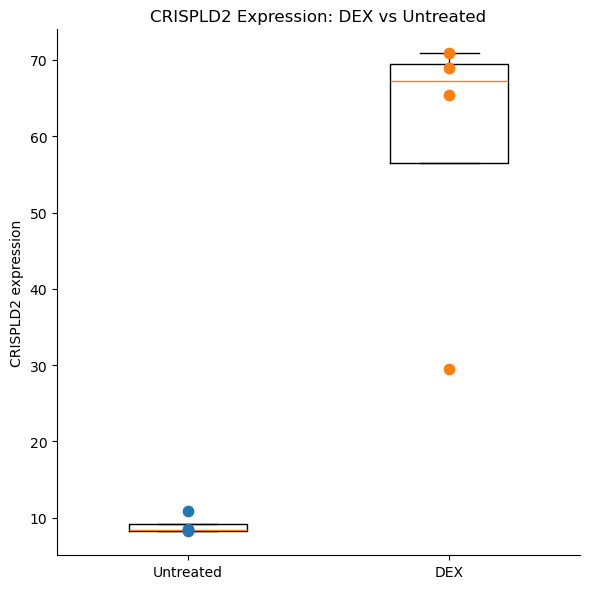

SVG figure saved to:
C:\Users\user\results\CRISPLD2_DEX_vs_Untreated.svg


In [147]:
# Part 10 — Reproduce CRISPLD2
# Publication-quality SVG plot

import pandas as pd
import matplotlib.pyplot as plt

# Get CRISPLD2 row
crispld2 = expr[
    expr["gene_id"].astype(str).str.upper() == "CRISPLD2"
].iloc[0]

# DEX and Untreated samples
dex_samples = [
    "Dex_LL14",
    "Dex_LL06",
    "Dex_LL02",
    "Dex_LL10"]

untreated_samples = [
    "Untreated_LL09",
    "Untreated_LL05",
    "Untreated_LL13",
    "Untreated_LL01"
]

# Expression values
dex_values = crispld2[dex_samples].astype(float).values
untreated_values = crispld2[untreated_samples].astype(float).values

# Create long-format data
plot_data = pd.DataFrame({
    "Condition": ["Untreated"] * 4 + ["DEX"] * 4,
    "Expression": list(untreated_values) + list(dex_values)
})

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Boxplot
ax.boxplot(
    [untreated_values, dex_values],
    positions=[1, 2],
    widths=0.45,
    patch_artist=False,
    showfliers=False
)

# Individual observations
ax.scatter(
    [1] * 4,
    untreated_values,
    s=55,
    zorder=3
)

ax.scatter(
    [2] * 4,
    dex_values,
    s=55,
    zorder=3
)

# Labels
ax.set_xticks([1, 2])
ax.set_xticklabels(["Untreated", "DEX"])
ax.set_ylabel("CRISPLD2 expression")
ax.set_title("CRISPLD2 Expression: DEX vs Untreated")

# Clean publication-style appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save as SVG
svg_path = r"C:\Users\user\results\CRISPLD2_DEX_vs_Untreated.svg"

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("SVG figure saved to:")
print(svg_path)

In [ ]:

Interpretation 

With  comapred to xamethasone-treated (DEX) samples,  the untreated samples of  CRISPLD2 expression plot was increased in expression .
All four DEX samples showed higher CRISPLD2 expression than the four untreated samples. This result reproduces the publication's finding that
dexamethasone induces CRISPLD2 expression. Therefore, our analysis provides strong evidence that the reported CRISPLD2 response to dexamethasone 
is reproduced in this dataset.

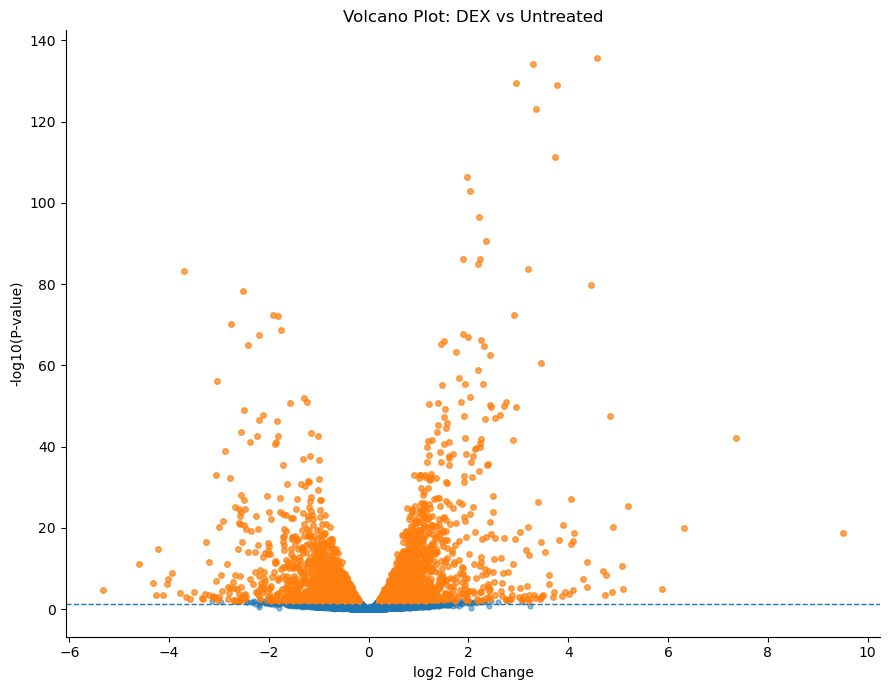

SVG figure saved to:
C:\Users\user\results\DEX_vs_Untreated_volcano.svg


In [148]:
#Part 11 — Volcano plot  

# DEX vs Untreated

import numpy as np
import matplotlib.pyplot as plt

# Make a copy of DESeq2 results
volcano = de.copy()

# Remove rows with missing values
volcano = volcano.dropna(
    subset=["log2FoldChange", "pvalue", "padj"]
).copy()

# Calculate volcano plot coordinates
volcano["minus_log10_pvalue"] = -np.log10(
    volcano["pvalue"].clip(lower=1e-300)
)

# Define significant genes using FDR < 0.05
volcano["significant"] = volcano["padj"] < 0.05

# Gene column
gene_column = volcano.columns[0]

# Genes to label
genes_to_label = [
    "CRISPLD2",
    "DUSP1",
    "KLF15",
    "PER1",
    "TSC22D3"
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 7))

# Non-significant genes
nonsig = volcano[~volcano["significant"]]

ax.scatter(
    nonsig["log2FoldChange"],
    nonsig["minus_log10_pvalue"],
    s=12,
    alpha=0.5
)

# Significant genes
sig = volcano[volcano["significant"]]

ax.scatter(
    sig["log2FoldChange"],
    sig["minus_log10_pvalue"],
    s=16,
    alpha=0.7
)

# FDR significance threshold
ax.axhline(
    -np.log10(0.05),
    linestyle="--",
    linewidth=1
)

# Add labels for important genes
for gene in genes_to_label:

    match = volcano[
        volcano[gene_column].astype(str).str.upper()
        == gene.upper()
    ]

    if len(match) > 0:

        row = match.iloc[0]

        ax.annotate(
            gene,
            xy=(
                row["log2FoldChange"],
                row["minus_log10_pvalue"]
            ),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold"
        )

# Axis labels
ax.set_xlabel("log2 Fold Change")
ax.set_ylabel("-log10(P-value)")
ax.set_title("Volcano Plot: DEX vs Untreated")

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save as SVG
svg_path = r"C:\Users\user\results\DEX_vs_Untreated_volcano.svg"

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("SVG figure saved to:")
print(svg_path)

In [ ]:
Interpretation

The volcano plot shows the distribution of genes according to their log2 fold changes and statistical significance for the DEX versus Untreated
comparison. Genes located farther to the right have increased expression following dexamethasone treatment, whereas genes farther to the left 
have decreased expression. Genes above the FDR significance threshold represent statistically significant differential expression. The presence
of significant genes on both sides of the plot indicates that dexamethasone affects the expression of multiple genes in both directions. CRISPLD2
and the other highlighted genes can be examined to determine whether the reported biological response is reproduced. In particular, a positive 
log2 fold change for CRISPLD2 indicates increased expression following dexamethasone treatment, consistent with the publication's reported finding.

In [150]:
# Part 12 — Reproducibility Assessment

paper_significant_genes = 316
our_significant_genes = len(significant)

print("Published study:", paper_significant_genes)
print("Our analysis:", our_significant_genes)
print("Difference:", our_significant_genes - paper_significant_genes)

Published study: 316
Our analysis: 3993
Difference: 3677


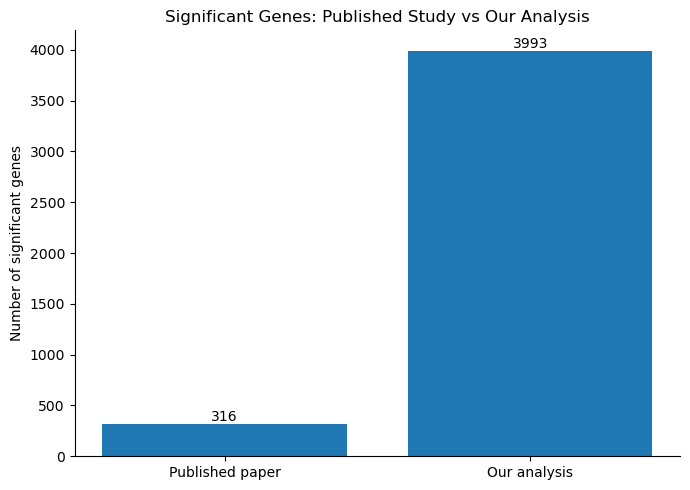

SVG figure saved to:
C:\Users\user\results\Part12_Reproducibility.svg


In [151]:
import matplotlib.pyplot as plt

paper = 316
our = len(significant)

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["Published paper", "Our analysis"],
    [paper, our]
)

ax.set_ylabel("Number of significant genes")
ax.set_title("Significant Genes: Published Study vs Our Analysis")

for i, value in enumerate([paper, our]):
    ax.text(i, value, str(value), ha="center", va="bottom")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

svg_path = r"C:\Users\user\results\Part12_Reproducibility.svg"

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("SVG figure saved to:")
print(svg_path)